In [159]:
# Daniel Berhane Araya 2022

from datetime import date, datetime, timedelta
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import StratifiedShuffleSplit
from scipy.stats import poisson, gamma, burr, fisk
from pandas.plotting import scatter_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler

import scipy as sp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import typing, random
import seaborn as sns
import calendar
import time

import h2o

h2o.init()

from h2o.estimators.deeplearning import H2OAutoEncoderEstimator


def load_input_data (fpath: str):
    
    """

    # Loads input data
    :param fpath: The path of the input file, relative to the working directory (i.e., the directory in which the script is run)
    :return: The input dataset as a pandas data frame

    """

    df = pd.read_csv(fpath)
    print ("File Loaded")

    return df


def date_hour_records  (year, interval):

    """
    
    This module will make sure that we have a record for every day of the year and for each day, a record of every hour and finally for each hour, a record of every 15 min. 
    By left joining data to this dataset, we can keep track of missing data both in the timestamp demand dataset as well as weather dataset.
    
    :param year     : The year of the dataset
           interval : The interval refers to the granularity of the demand dataset. In this project, the timestamp dataset was collected every 15 minutes.
    :return         : A dataframe which contains the date and hour columns for the input year - for each day of the year, 24 hours of rows are populated.
                      The output is a dataframe with 365/366 * 24 rows
    """
    
    # check if the year is a leap year
    if (calendar.isleap(year)):
        days = 366
    else:
        days = 365
    
    # start date
    sdate = date(year, 1, 1)
    
    # end date
    edate = date(year + 1, 1, 1)
    
    # create a list of days from sdate to edate, because the edate is included "- timedelta (days=1)" subtracts one day
    dates_list = pd.date_range(sdate, edate - timedelta(days=1), freq='d')
    date_df = pd.DataFrame(dates_list, columns= {'Date'})
    
    # repeat each date row 24 times and concatenate at the end. 
    date_df = pd.concat([date_df] * 24, ignore_index=True)
    date_df.sort_values(inplace=True, by='Date')
    date_df.reset_index(inplace=True, drop=True)
  
    # prepare hourly rows and repeat them for 365/366 days
    hour_list = [n for n in range(24)]
    hour_df = pd.DataFrame(hour_list, columns = {'Hour'})
    hour_df = pd.concat([hour_df] * days, ignore_index=True)
    hour_df.reset_index(inplace=True, drop=True)
    
    # Merge the daily and hourly records and then merge the resulting dataframe with the minute records
    day_hour_df = pd.merge(date_df, hour_df, how='inner', left_index=True, right_index=True)
    day_hour_df.sort_values (by=['Date', 'Hour'])
    day_hour_df.set_index (['Date', 'Hour'], inplace=True)

    return (day_hour_df)


def minute_records (year):
    if calendar.isleap(year):
        days = 366
    else:
        days = 355

    minute_list = [n for n in range (0, 60, 15)]
    minute_list_df = pd.DataFrame (minute_list, columns={'Minute'})
    minute_index = pd.concat ([minute_list_df]*days*24, ignore_index=True)
    minute_index.reset_index(inplace=True)
    minute_index.rename(columns={0: 'Minute'}, inplace=True)

    return (minute_index)


def rolling_window(demand, window_size):
    
    """
    :param demand      : The demand dataset (one column)
           window_size : The size of the desired overlapping sliding window (in this project, I am examinining an hourly record measured 
                         every 15 minute interval, hence the window_size is 5 [0, 15, 30, 45, 0])
    :return            : A dataframe (5 columns) which is a sliding window of size 5 
    """
    shape = demand.shape[:-1] + (demand.shape[-1] - window_size + 1, window_size)
    strides = demand.strides + (demand.strides[-1],)
    return np.lib.stride_tricks.as_strided(demand, shape=shape, strides=strides)


def demand_temporal_features (demand_raw, year, window_size):
    
    """
    :param year           : The year of the dataset
           df             : Timestamp demand data frame
           window_size    : The size of the sliding window
    
    :return               : Data frame with temporal features along with an hourly window of demand records that slides every 15
    """
    
    df = demand_raw.copy()
    
    df.rename(columns={"slottime_GMT":"Timestamp"}, inplace=True)
    # Extract temporal features from the timestamp field
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df['Year'] = pd.DatetimeIndex(df['Timestamp']).year
    df['Month'] = df['Timestamp'].dt.month
    #df['Month'] = df['Month'].astype("int64")
    
    df['DayOfMonth'] = pd.DatetimeIndex(df['Timestamp']).day
    df['Weekday'] = df['Timestamp'].dt.weekday
    
    df['Weekday'] = df['Weekday'].astype("Int64")
      
    df['Hour'] = pd.DatetimeIndex(df['Timestamp']).hour
    df['Minute'] = pd.DatetimeIndex(df['Timestamp']).minute
    df['Date'] = df['Timestamp'].dt.date

    df = df[['Timestamp', 'Date', 'Year', 'Month', 'DayOfMonth', 'Weekday', 'Hour', 'Minute', 'Demand']]
    
    # create an hourly overlapping sliding window - it slides every 15 minutes
    demand_sw = rolling_window (df['Demand'].values, 5)
    demand_sw_df = pd.DataFrame (demand_sw)
    
    # Join the temporal features with the sliding window information
    demand_sw_time = pd.merge (df, demand_sw_df, how='inner', left_index=True, right_index=True)
    demand_sw_year = demand_sw_time[demand_sw_time['Year'] == year]
    demand_sw_year.set_index(['Date','Hour','Minute'], inplace=True)

    return (demand_sw_year)

def weather_data_processed (year, interval, fpath: str):
    
    """
    :param year: (The year of the weather data)
    :return: A dataframe which contains the date and hour columns for the input year - for each day of the year, 24 hours of rows are populated.
             The output is a dataframe with 365/366 * 24 rows
    """
    
     # Get a dataframe with day, hour and min for the year and interval provided
    date_df = date_hour_records (year, interval)
    # Read weather data for the same year
    weather_year = pd.read_csv(fpath)
    
    # The weather data was not collected at specific intervals. For intance the data is collected at  7:15 AM and then 7:56 AM. The column 'Time_int'
    # will get the hour and later this field will be used to remove duplicate measurements in a hour so that we retain only one measurement for each hour.
    weather_year['Time_int'] = pd.to_datetime(weather_year['Time']).dt.hour
    
    # Remove duplicates so that we retain only one hourly weather data. To keep the most up to date weather measument, the last record is kept instead of the first
    weather_year = weather_year.drop_duplicates(subset=['Date', 'Time_int'], keep='last').reset_index(drop=True)
    
    weather_year['Date'] = pd.to_datetime(weather_year['Date'])
    weather_year.rename(columns={'Time_int': 'Hour'}, inplace=True)
    weather_year.set_index(['Date', 'Hour'], inplace=True)
    weather_merged = pd.merge(date_df, weather_year, how='left', left_on =['Date', 'Hour'], right_on=['Date', 'Hour'])
    

    weather_merged.reset_index(inplace=True)
    weather_merged['Month'] = weather_merged['Date'].dt.month
    weather_merged = weather_merged[
        ['Date', 'Month', 'Hour', 'Temperature', 'Humidity', 'Pressure', 'Wind Speed', 'Wind Gust', 'Precipitation',
         'Dew Point']]
    weather_merged['Month'] = weather_merged['Month'].round().astype(int)
 
    
    # convert the weather columns to float which will be important when the mean is calculated in a few lines for imputation purposes
    weather_merged_c = clean_weather_dtype(weather_merged)
    
    # In this project missing weather data is imputted using the mean value of each hour of every month. For instance, missing temperature at 7 am in January is imputted by using
    # the mean value of all 7 am temperature values for January. Weather data is seasonal and it would be more appropriate to use the right season, in this case month for imputation
    
    imputted_values = weather_merged_c.groupby(['Month', 'Hour']).mean()
    
    # Join the mean values to prepare for later imputation
    weather_imputted = pd.merge(weather_merged_c, imputted_values, how="left", left_on=['Month', 'Hour'],
                                right_on=['Month', 'Hour'])

    # Imput missing data
    weather_imputted.Temperature_x.fillna(weather_imputted.Temperature_y, inplace=True)
    weather_imputted['Dew Point_x'].fillna(weather_imputted['Dew Point_y'], inplace=True)
    weather_imputted.Humidity_x.fillna(weather_imputted.Humidity_y, inplace=True)
    weather_imputted['Wind Speed_x'].fillna(weather_imputted['Wind Speed_y'], inplace=True)
    weather_imputted['Wind Gust_x'].fillna(weather_imputted['Wind Gust_y'], inplace=True)
    weather_imputted.Pressure_x.fillna(weather_imputted.Pressure_y, inplace=True)
    weather_imputted.Precipitation_x.fillna(weather_imputted.Precipitation_y, inplace=True)
    
    # Rename columns that were in common from the merger
    weather_imputted.rename(
        columns={'Temperature_x': 'Temperature', 'Dew Point_x': 'DewPoint', 'Humidity_x': 'Humidity',
                 'Pressure_x': 'Pressure', 'Wind Speed_x': 'WindSpeed', 'Wind Gust_x': 'WindGust',
                 'Precipitation_x': 'Precipitation'}, inplace=True)

    weather_imputted = weather_imputted[
        ['Date', 'Hour', 'Temperature', 'DewPoint', 'Humidity', 'WindSpeed', 'WindGust', 'Pressure',
         'Precipitation', 'Month']]
    
    # As the weather data is hourly record, in this project, it is assumed that the weather stays the same for that hour, hence the records for the hour
    # are duplicated for the hour, hour + 15, hour + 30, hour + 45 miutes (4 times)
    
    weather_imputted = weather_imputted.loc[weather_imputted.index.repeat(4)]

    weather_imputted.reset_index(inplace=True, drop=True)
    
    # Prepare the minute rows
    minute_ind = minute_records(year)

    # The minutes are merged to the weather records
    weather_data_year = pd.merge(weather_imputted, minute_ind, how="inner", left_index=True, right_index=True)

    weather_data_year.set_index(['Date', 'Hour', 'Minute'], inplace=True)

    return (weather_data_year)



def clean_weather_dtype(weather_data):
    
    """
    Some records in the weather data has the ',' delimiter every three digits which makes it difficult to convert the column to float. This module replaces the ',' with
    a ' ' before converting it to float.
    
    :param weather_data   : A dataframe containing temporal as well as weather data
           
    :return               : Converts the columns to float
    """
        
    if (weather_data['Precipitation'].dtype == object):
        weather_data['Precipitation'] = weather_data['Precipitation'].str.replace(',', '').astype(float)

    if (weather_data['Dew Point'].dtype == object):
        weather_data['Dew Point'] = weather_data['Dew Point'].str.replace(',', '').astype(float)

    if (weather_data['Wind Speed'].dtype == object):
        weather_data['Wind Speed'] = weather_data['Wind Speed'].str.replace(',', '').astype(float)

    if (weather_data['Wind Gust'].dtype == object):
        weather_data['Wind Gust'] = weather_data['Wind Gust'].str.replace(',', '').astype(float)

    if (weather_data['Pressure'].dtype == object):
        weather_data['Pressure'] = weather_data['Pressure'].str.replace(',', '').astype(float)

    if (weather_data['Humidity'].dtype == object):
        weather_data['Humidity'] = weather_data['Humidity'].str.replace(',', '').astype(float)

    if (weather_data['Temperature'].dtype == object):
        weather_data['Temperature'] = weather_data['Temperature'].str.replace(',', '').astype(float)

    return (weather_data)


def weather_combined_data (weather_data, sw_demand, year):
    
    # The sliding window demand data is merged to the weather data
    
    weather_sw_demand = pd.merge(weather_data, sw_demand, how="left", left_index=True, right_index=True)
       
    weather_sw_demand.reset_index(inplace=True)
   
    
    # Remove duplicate features (Month_y) or fields that are not important to the learning process ('Day of Month or year') and demand is already included as a sliding window
    weather_sw_demand.drop(['index', 'Month_y', 'DayOfMonth', 'Demand', 'Year', 'Date'], axis=1, inplace=True)

    weather_sw_demand.rename(
       columns={'Month_x': 'Month', 0: 'Demand_0', 1: 'Demand_15', 2: 'Demand_30', 3: 'Demand_45', 4: 'Demand_60'},
       inplace=True)
    
    # After analysing the dataset, Weekday is missing for the records with missing demand data. It's to be noted that Hour, Minute and Month are not missing because we are using
    # these from constracted full annual records. When we later do stratified train-test split, if we have any missing data (na) on any of the features used for stratified sampling
    # an error is thrown, therefore, the below line will for convinience fill forward the weekday. However it is to be noted that these records are the same records that have missing
    # demand and it is only because we will be removing these records that we are filling forward. If future implemetations include imputation techniques for demand, this line will be 
    # removed
    
    weather_sw_demand.loc[:,'Weekday'] = weather_sw_demand.loc[:,'Weekday'].ffill()
    
    # There are some missing data in demand and these are only a few and have been removed from the dataset. Since we are dealing with a window of information, any record with
    # missing demand is entirely removed
    
    demand_na = weather_sw_demand.isna().sum()
    
    # Remove a row that has any missing value
    #   weather_sw_demand.dropna(axis=0, inplace=True)
        
    weather_sw_demand['Weekday'] = weather_sw_demand['Weekday'].astype(int)



    
    return (weather_sw_demand, demand_na)


def generate_features (df):
    
    df['Demand_mean'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].mean(axis=1) 
    df['Demand_sd'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].std(axis=1)
    
    return (df)


def missing_treatment (df):
    
    df.dropna(inplace=True)
    return df



def Quantile_transform (feature):
    d = np.array (feature)
    # reshape data to have rows and columns
    data = d.reshape((len(d),1))
    # quantile transform the raw data
    quantile = QuantileTransformer(output_distribution='normal')
    feature_t= quantile.fit_transform(data)
    feature_t=feature_t.flatten()
    # histogram of the transformed data
    return pd.Series(feature_t)

def squared_transform (feature):
    d = np.array (feature)
    feature_t = np.sqrt(d)
    feature_t = feature_t.flatten()
    return pd.Series(feature) 


def boxcox_transform (feature):
    feature_c = np.array (feature)
    feature_t = stats.boxcox (feature_c, -1)
    feature_t = feature_t.flatten()
    return pd.Series (feature)  


def temporal_feature_cyclic (data):
    
    minutes_in_hour = 60
    hours_in_day = 24
    days_in_week = 7
    months_in_year = 12
    
    df = data.copy()
    
    df['sin_minutes'] = np.sin(2*np.pi*df['Minute']/minutes_in_hour)
    df['cos_minutes'] = np.cos(2*np.pi*df['Minute']/minutes_in_hour)
    
    df['sin_hours'] = np.sin(2*np.pi*df['Hour']/hours_in_day)
    df['cos_hours'] = np.cos(2*np.pi*df['Hour']/hours_in_day)
    
    df['sin_days'] = np.sin(2*np.pi*df['Weekday']/days_in_week)
    df['cos_days'] = np.cos(2*np.pi*df['Weekday']/days_in_week)
    
    df['sin_months'] = np.sin(2*np.pi*df['Month']/months_in_year)
    df['cos_months'] = np.cos(2*np.pi*df['Month']/months_in_year)
    
    #df.drop(['Hour', 'Weekday', 'Month'], axis=1, inplace=True)
    
    return (df)


def train_test_splitter (df):
    
    split = StratifiedShuffleSplit (n_splits=1, test_size =0.2, random_state=42)

    for train_index, test_index in split.split (df, df[['Hour', 'Month', 'Weekday']]):
        strat_train_set = df.iloc[train_index]
        strat_test_set = df.iloc[test_index]
        
    return strat_train_set, strat_test_set




def gen_artificial_anomalous (row):
    
    # find parameters of low-demand distribution
    # find parameters of high-demand distribution
    # if it's a weekday and hour >= 1 and hour <= 12 then generate 5 random numbers from the high-demand distribution 
    # if it's a weekday and hour > 12 and hour <= 23 then generate 5 random numbers from the low-demand distribution
    # if it's a weekend, then generate 5 random numbers from the high-demand distribution
    
    # high electric demand parameters
    c_high = 42.80
    d_high = 0.66
    loc_high = -1.16
    scale_high = 266.97
    
    # low electric demand parameters
    c_low = 42.53
    loc_low = -0.65
    scale_low = 222.14
    
    hour = int (row['Hour'])
    
    if ((hour >= 1 & hour <= 12)) | (hour >= 22) :
        # Note that the random_state is None so that we don't keep on generating the same random number
        demand = burr.rvs(c_high, d_high, loc=loc_high, scale=scale_high, size=5, random_state=None)
    
    elif (hour > 12 & hour) <= 21:
        demand = fisk.rvs(c_low, loc=loc_low, scale=scale_low, size=5, random_state=None)
    
    demand = np.around(demand,1)
    
    row ['Demand_0'] = demand [0]
    row ['Demand_15'] = demand [1]
    row ['Demand_30'] = demand [2]
    row ['Demand_45'] = demand [3]
    row ['Demand_60'] = demand [4]
    
    return row

def gen_artificial_anomalous_2 (row, demand_train_high, demand_train_low):
    
    hour = int (row['Hour'])
    month = int (row['Month'])
    weekday = int (row['Weekday'])
    
    # find parameters of low-demand distribution
    # find parameters of high-demand distribution
    # if it's a weekday and hour >= 1 and hour <= 12 then generate 5 random numbers from the high-demand distribution 
    # if it's a weekday and hour > 12 and hour <= 23 then generate 5 random numbers from the low-demand distribution
    # if it's a weekend, then generate 5 random numbers from the high-demand distribution
    
    
    
    if ((hour >= 1 & hour <= 12)) | (hour >= 22) :
        index_high = random.sample (range(0,len(demand_train_high)), 5)
        demand = demand_train_high[index_high]
        
    elif (hour > 12 & hour) <= 21:
        index_high = random.sample (range(0,len(demand_train_low)), 5)
        demand = demand_train_high[index_low]
    
    demand = np.around(demand,1)
    
    row ['Demand_0'] = demand [0]
    row ['Demand_15'] = demand [1]
    row ['Demand_30'] = demand [2]
    row ['Demand_45'] = demand [3]
    row ['Demand_60'] = demand [4]
    
    return row



Checking whether there is an H2O instance running at http://localhost:54321 . connected.


H2O_cluster_uptime:,1 hour 4 mins
H2O_cluster_timezone:,America/Toronto
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.30.0.4
H2O_cluster_version_age:,"2 years, 2 months and 18 days !!!"
H2O_cluster_name:,H2O_from_python_daniel_uwxqoc
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.246 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


## Main ##

In [160]:
import pandas as pd
import numpy as np

import os

# -- Project imports

demand_input_path = '/Users/daniel/projects/anomaly_detection/electricB.csv'
weather_input_path ='/Users/daniel/projects/Python/anomaly_detection/dataset/'

years = [2016, 2017, 2018, 2019]
# years = [2016]


# The interval of the timestamp
interval = 15

# Hourly sliding window dataset. The timestamp interval is 15 min. [0, 15, 30, 45, 0]
window_size = 5

data = pd.DataFrame()

# missing data
missing_demand = 0

for year in years:              
    filepath = os.path.join(weather_input_path, "hourly_weather_" + str(year) + '.csv')        
    print (filepath)             
                   
    demand = load_input_data (demand_input_path)
 
    demand_sw = demand_temporal_features (demand, year, window_size)
    
    weather = weather_data_processed (year, interval, filepath)
    
    # test = weather_combined_data (weather, demand_sw, year)
    
    weather_all, number_na = weather_combined_data (weather, demand_sw, year)
    
    missing_demand = number_na + missing_demand
    
    data = pd.concat ([data, weather_all], axis=0)
    
    data.drop ('Timestamp', axis=1, inplace=True)


/Users/daniel/projects/Python/anomaly_detection/dataset/hourly_weather_2016.csv
File Loaded


/Users/daniel/opt/anaconda3/envs/smart_building/lib/python3.10/site-packages/pandas/core/indexes/base.py:327: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  return libjoin.left_join_indexer_unique(sv, ov)


/Users/daniel/projects/Python/anomaly_detection/dataset/hourly_weather_2017.csv
File Loaded


/Users/daniel/opt/anaconda3/envs/smart_building/lib/python3.10/site-packages/pandas/core/indexes/base.py:327: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  return libjoin.left_join_indexer_unique(sv, ov)


/Users/daniel/projects/Python/anomaly_detection/dataset/hourly_weather_2018.csv
File Loaded


/Users/daniel/opt/anaconda3/envs/smart_building/lib/python3.10/site-packages/pandas/core/indexes/base.py:327: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  return libjoin.left_join_indexer_unique(sv, ov)


/Users/daniel/projects/Python/anomaly_detection/dataset/hourly_weather_2019.csv
File Loaded


/Users/daniel/opt/anaconda3/envs/smart_building/lib/python3.10/site-packages/pandas/core/indexes/base.py:327: FutureWarning: Comparison of Timestamp with datetime.date is deprecated in order to match the standard library behavior. In a future version these will be considered non-comparable. Use 'ts == pd.Timestamp(date)' or 'ts.date() == date' instead.
  return libjoin.left_join_indexer_unique(sv, ov)


In [161]:
data.head()

,Hour,Minute,Temperature,DewPoint,Humidity,WindSpeed,WindGust,Pressure,Precipitation,Month,Weekday,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60
0,0,0,-4.166667,-8.208333,75.416667,17.416667,11.416667,972.704167,0.000000,1,4,214.0,214.9,211.9,216.3,211.7
1,0,15,-4.166667,-8.208333,75.416667,17.416667,11.416667,972.704167,0.000000,1,4,214.9,211.9,216.3,211.7,206.3
2,0,30,-4.166667,-8.208333,75.416667,17.416667,11.416667,972.704167,0.000000,1,4,211.9,216.3,211.7,206.3,209.3
3,0,45,-4.166667,-8.208333,75.416667,17.416667,11.416667,972.704167,0.000000,1,4,216.3,211.7,206.3,209.3,209.2
4,1,0,-4.956522,-8.869565,75.130435,16.217391,10.695652,972.863913,0.013043,1,4,211.7,206.3,209.3,209.2,211.5


### Train-Test Split ###

Demand is highly seasonal, hence Hour, Month and Weekday are very important features. Depending on whether the building is residential or office, hourly demand varies greatly. For instance for residential, the demand would peak early in the morning when residents wake up and prepare to go to work or school and later in the evening when the residents come back home. Where as for office demand peaks early mornig hours and stays constant through out the day and then is low when everyone leaves home. This assumption is based on pre covid assessment because the work hours setting is now shifting to working from home for the most. Similarly, weekday and month also affect demand. Therefore the test set is generated by stratifying over these feature. Moreover, we know that the demand is also affected by the weekday as well as Month, hence we have stratified along all these features. The train test needs to be updated to accomodate future data so that the test data remains consistent.

In [162]:
# def train_test_splitter (df):
    
#    split = StratifiedShuffleSplit (n_splits=1, test_size = 0.2 , random_state=42)

#    for train_index, test_index in split.split (df, df[['Hour', 'Month', 'Weekday']]):
#        strat_train_set = df.iloc[train_index]
#        strat_test_set = df.iloc[test_index]
        
#    return strat_train_set, strat_test_set

strat_train_set, strat_test_set = train_test_splitter (data)
print ("Train: " + str(strat_train_set.shape[0]), "     Test: " + str (strat_test_set.shape[0]), "        Number of features: " + str (strat_test_set.shape[1]))

Train: 109900      Test: 27476         Number of features: 16


In [163]:
# Stratified by hour

dataset = data['Hour'].value_counts()/len(data['Hour'])
test_data = strat_test_set['Hour'].value_counts()/len(strat_test_set['Hour'])
hour_stratified = pd.concat([dataset, test_data], axis=1)
hour_stratified.reset_index (inplace=True)
hour_stratified.columns=['Hour', 'Entire Dataset', 'Test Dataset']
hour_stratified.set_index('Hour', inplace=True)

In [164]:
# Confirm hourly stratified test dataset - similar analysis can be done for Weekday and Month 
# There is 4.1% of each hour in the test dataset (similar to the entire dataset proportion)
hour_stratified.sort_values(by="Hour")

,Entire Dataset,Test Dataset
Hour,,
0,0.041667,0.041673
1,0.041667,0.041746
2,0.041667,0.041709
3,0.041667,0.041673
4,0.041667,0.041746
5,0.041667,0.041709
6,0.041667,0.041673
7,0.041667,0.041673
8,0.041667,0.041709


We will call the training dataset as *'demand_train'*. The model will be tested for its sensitivity and specificity. A part of the dataset split above will be used to evaluate the specificity of the model. The assumption is that the data extracted is normal (negative). We will call this dataset as  'negative_test'.  The next step is to generate an artificial anomalous dataset which we will call as 'positive_test' and will be used to evaluate the sensitivity of the mode</pre>

In [165]:
# Training dataset
demand_train = strat_train_set.copy()

# negative test dataset
negative_test = strat_test_set.copy()
demand_train.head()

,Hour,Minute,Temperature,DewPoint,Humidity,WindSpeed,WindGust,Pressure,Precipitation,Month,Weekday,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60
22837,21,15,17.0,11.0,67.0,9.0,0.0,980.42,0.0,8,0,237.9,235.0,219.1,226.3,229.7
1197,11,15,-7.0,-14.0,57.0,0.0,0.0,989.53,0.0,1,6,224.9,223.3,212.0,216.4,218.7
19113,2,15,22.0,22.0,100.0,9.0,0.0,973.26,0.0,7,4,238.6,236.0,236.7,239.5,239.9
11393,16,15,11.0,-2.0,40.0,11.0,0.0,976.19,0.0,4,3,263.0,264.8,263.0,263.1,268.1
6076,7,0,-4.0,-8.0,77.0,15.0,0.0,982.05,0.0,3,0,228.6,231.2,228.1,228.3,226.9


### Missing data and outlier treatment ###

> Real-world *energy* **data** is full of outliers and missing data, this could be from equipment or power failure or other human-related errors. For instance, a negative demand value would be erroneaous as we need to always have positive demand value. The approach adopted in this project to treat missing data is as follows: 

>

> - Missing demand values were relatively few (1.3%) and for this reason, they were removed. There were several other options, this includes imputting the demand using median or mean of the approapriate hour, month and weekday. Note that the Hour, Minute, Moth and Weekday have similar missing values but in the below, we can see that Hour and Minute have no missing data because of the way the data was prepared (All hour and minute to later left join with demand data to identify missing values).

> - Missing weather data: Weather data is highly seasonal to month and hour and hence missing values were imputted by using the mean weather parameter for the specific month and hour. In future studies, more rigorous functions will explored to fit historic weather data for imputation purposes.

> - In this version of the project, the only outlier test that has been done was to check if there are negative demand values. Future work will explore multivariate outlier analysis techniques

In [166]:
# Missing data percentage
(demand_train.isna().sum()/len(demand_train))*100

Hour             0.000000
Minute           0.000000
Temperature      0.000000
DewPoint         0.000000
Humidity         0.000000
WindSpeed        0.000000
WindGust         0.000000
Pressure         0.000000
Precipitation    0.000000
Month            0.000000
Weekday          0.000000
Demand_0         1.307552
Demand_15        1.307552
Demand_30        1.307552
Demand_45        1.307552
Demand_60        1.307552
dtype: float64

In [167]:
# Missing data treament

# def missing_treatment (df):
    
#    df.dropna(inplace=True)
#    return df

demand_train = missing_treatment (demand_train)

In [168]:
demand_train.isna().sum()

Hour             0
Minute           0
Temperature      0
DewPoint         0
Humidity         0
WindSpeed        0
WindGust         0
Pressure         0
Precipitation    0
Month            0
Weekday          0
Demand_0         0
Demand_15        0
Demand_30        0
Demand_45        0
Demand_60        0
dtype: int64

### Feature Generation ###

Partly, feature generation has been performed when a sliding window of hourly electric demand has been generated. In the future implementation, this implementation will be modularized to enable new other feature generation techniques to seemlessly integrate with the current framework.

In [169]:
# def generate_features (df):
    
#    df['Demand_mean'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].mean(axis=1) 
#    df['Demand_sd'] = df[['Demand_0', 'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60']].sd(axis=1)
    
#    return (df)

demand_train_f = generate_features (demand_train)
demand_train_f.head()

,Hour,Minute,Temperature,DewPoint,Humidity,WindSpeed,WindGust,Pressure,Precipitation,Month,Weekday,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Demand_mean,Demand_sd
22837,21,15,17.0,11.0,67.0,9.0,0.0,980.42,0.0,8,0,237.9,235.0,219.1,226.3,229.7,229.60,7.402702
1197,11,15,-7.0,-14.0,57.0,0.0,0.0,989.53,0.0,1,6,224.9,223.3,212.0,216.4,218.7,219.06,5.223313
19113,2,15,22.0,22.0,100.0,9.0,0.0,973.26,0.0,7,4,238.6,236.0,236.7,239.5,239.9,238.14,1.718430
11393,16,15,11.0,-2.0,40.0,11.0,0.0,976.19,0.0,4,3,263.0,264.8,263.0,263.1,268.1,264.40,2.205675
6076,7,0,-4.0,-8.0,77.0,15.0,0.0,982.05,0.0,3,0,228.6,231.2,228.1,228.3,226.9,228.62,1.580190


### Artificial Anomalous Dataset ###

Before generating anomalous artificial dataset, let's analyze the distribution of the dataset's hourly mean demand and daily mean demand

#### Hourly Electric Demand Distribution ####

In [170]:
new_demand = demand_train_f.reset_index(drop=True)

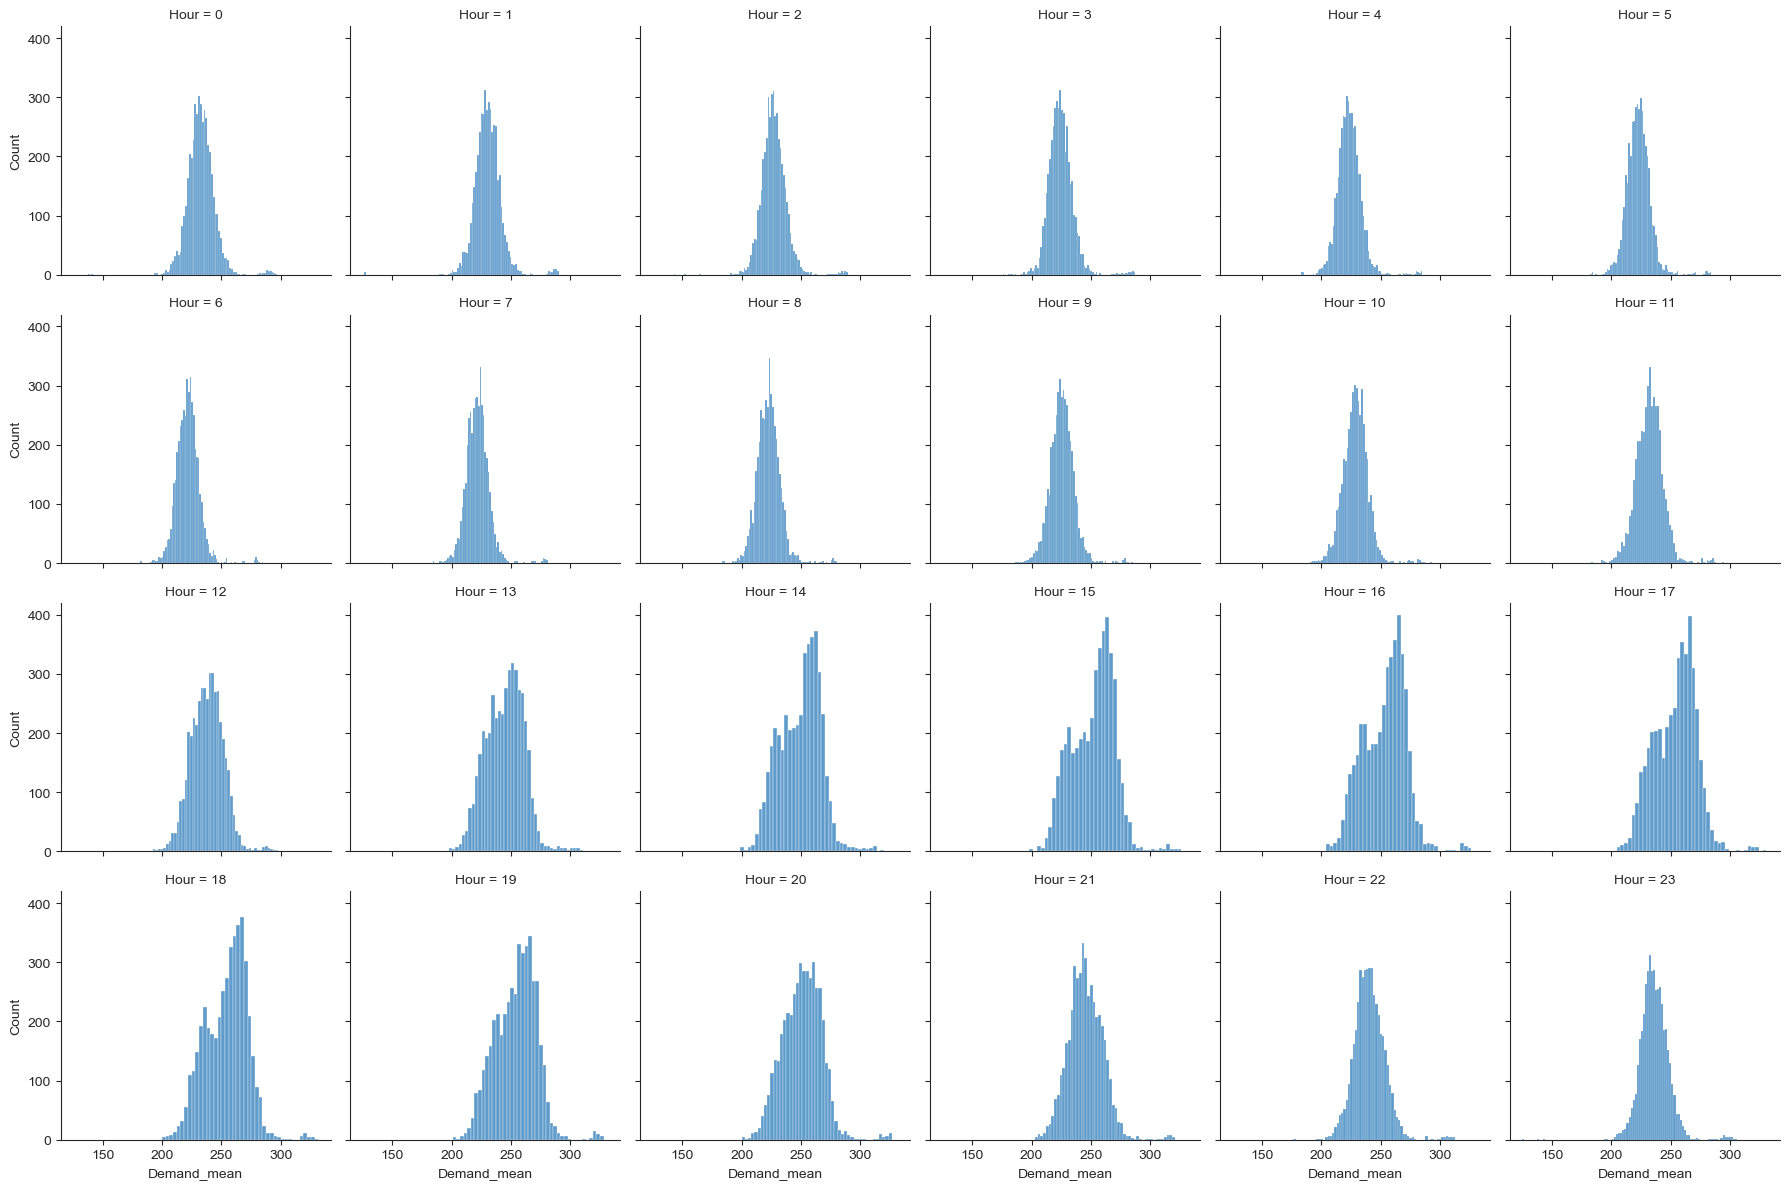

In [171]:
# Mean hourly electric demand distribution
sns.set_style("ticks")
g = sns.FacetGrid(new_demand, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean" , color="#2b7bba")

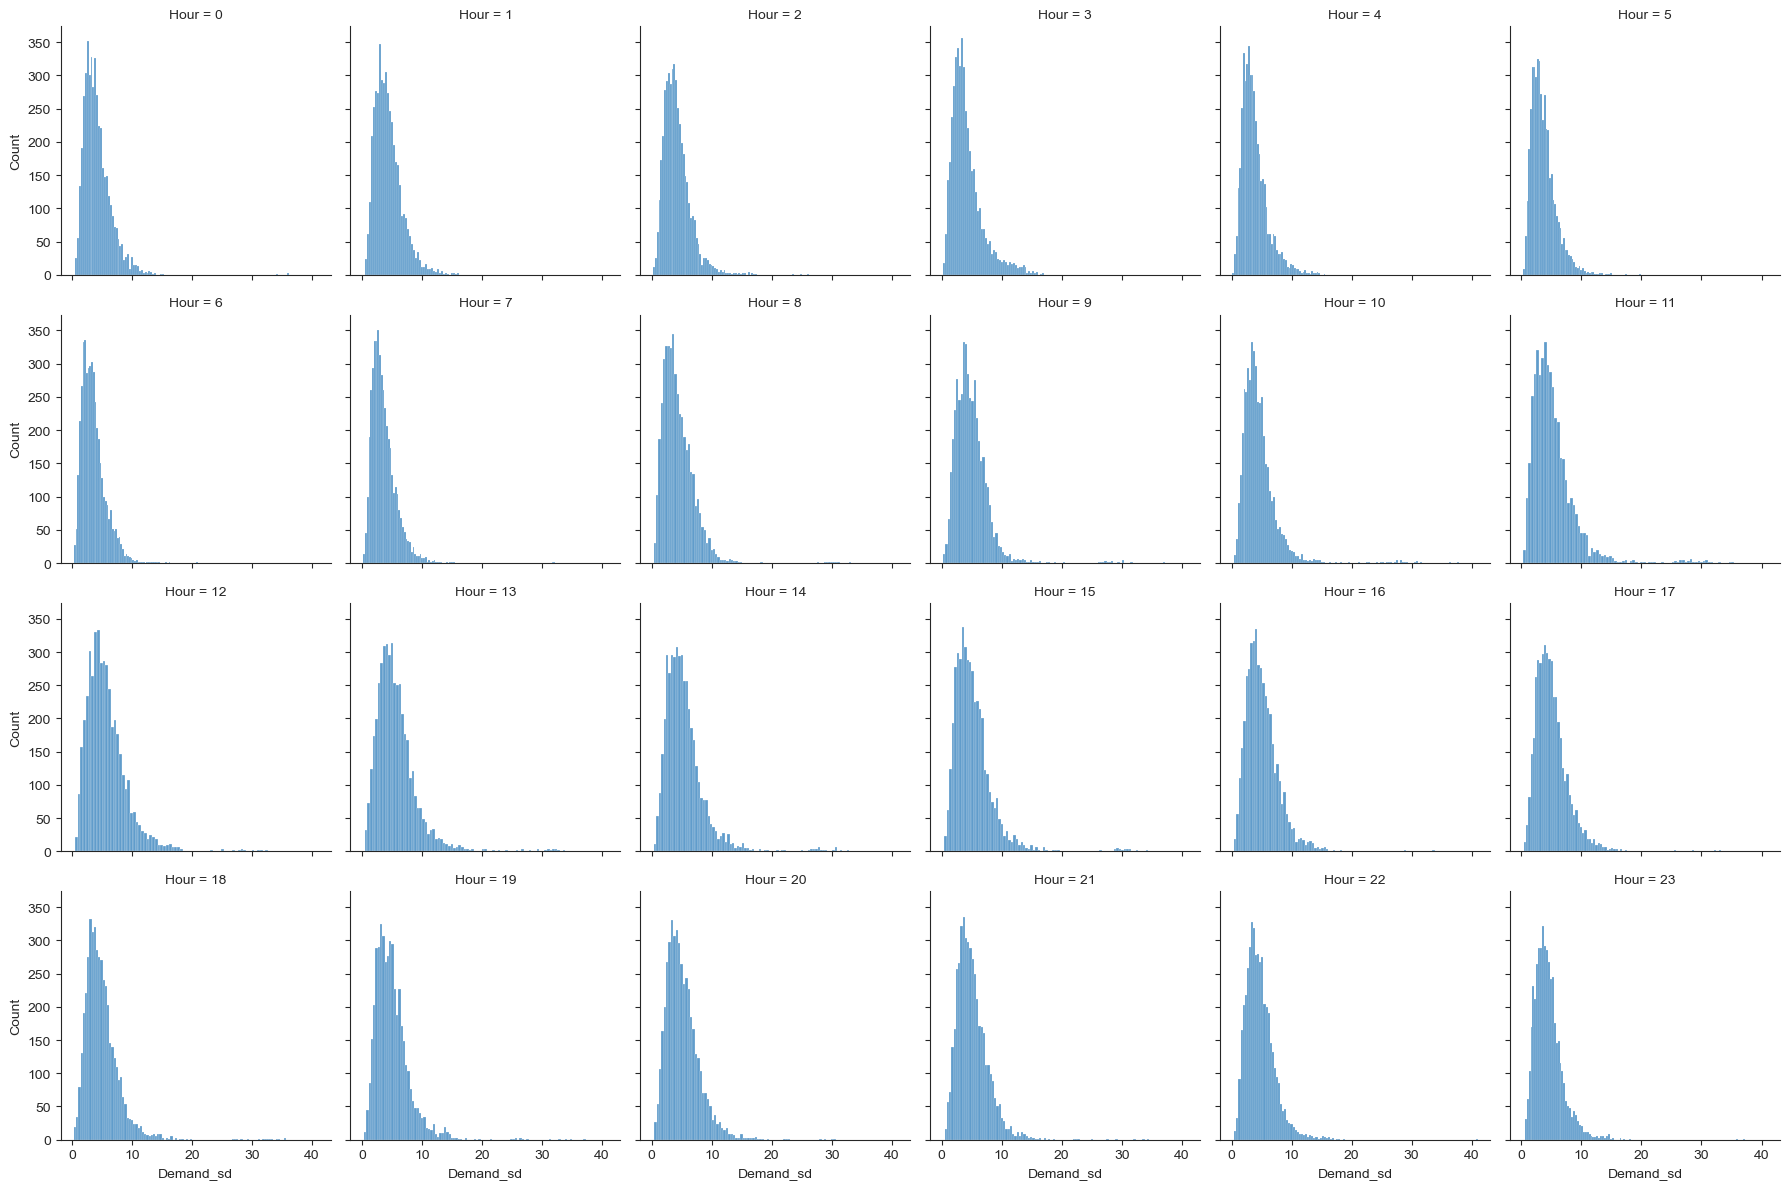

In [172]:
# Hourly electric demand standard deviation distribution
sns.set_style("ticks")
g = sns.FacetGrid(new_demand, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_sd" , color="#2b7bba")

### Daily Electric Demand Distribution ###

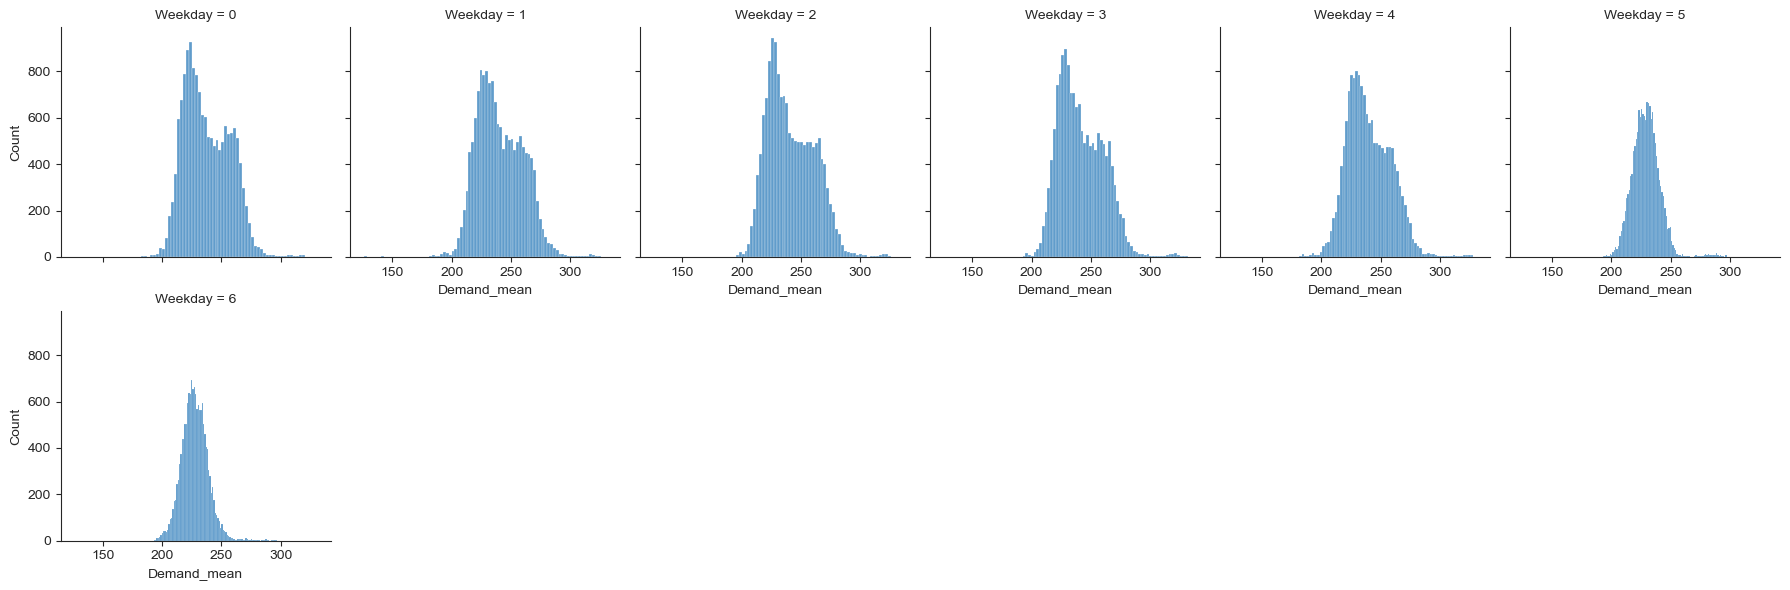

In [173]:
# Daily electric demand distribution
g = sns.FacetGrid(new_demand, col="Weekday", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color = "#2b7bba")
sns.set_style("ticks")

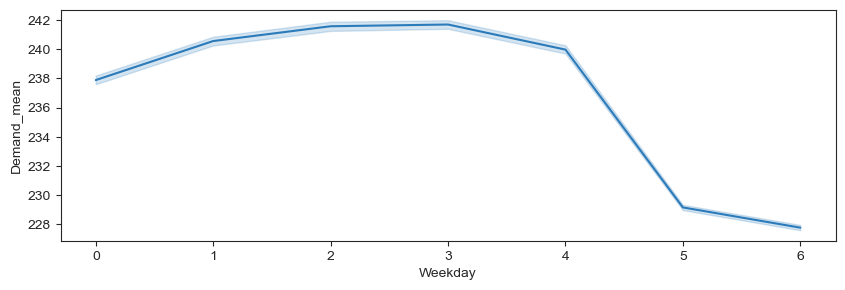

In [85]:
_ , ax = plt.subplots(figsize = (10, 3))
ax = sns.lineplot(data=new_demand , x="Weekday", y="Demand_mean", color="#2b7bba")

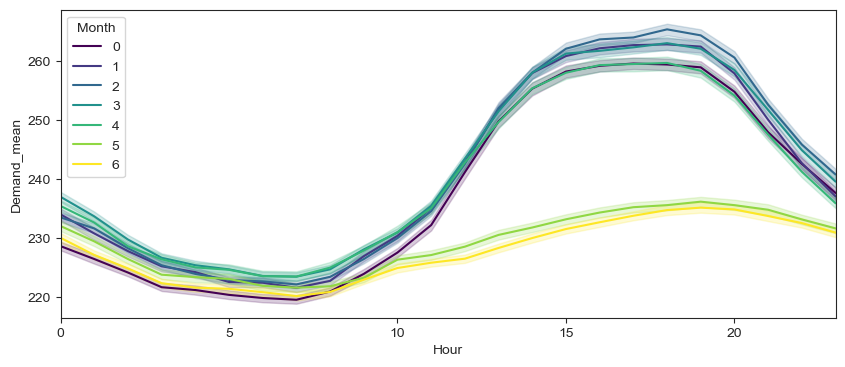

In [86]:
_ , ax = plt.subplots(figsize = (10, 4))
ax = sns.lineplot(data=new_demand, x="Hour", y="Demand_mean", hue="Weekday", palette="viridis", legend='full')
plt.xlim(0, 23)
_ = ax.legend(loc='upper left', title='Month')

As shown in the above charts, the hourly demand can be classified into high-demand hours (peak demand hours), i.e., weekdays [14-20], low-demand hours - weekdays [3-11] and the rest of the hours for weekday, the demand has medium. Moreover, if we observe the daily demand values, we can classify it into weekday (high demand) and weekend (low demand) days.

In this project, we will equally focus on both higher values of demand when we expect low, which shows energy waste as well as low values of demand when we expect high, which might indicate device malfunction

Several approaches can be used to generate artrificial anomalous dataset. For simplicity, the approach adopted in this project is to first identify the high-demand and low-demand hours/days, subsquently, extract the mean hourly demand for these two demand categories. Once we have the mean demand for these two categories, we search for the right distribution to fit these datasets. After getting the parameters of the right distributions, we generate random number from these distributions to populate the artificial anomalous dataset. For weekdays, low-demand hours are assigned demand values from the high-demand hours and similarly high-demand hours are assigned demand values from the low-demand hours. For weekends, since the demand is always low, high demand values will be used.

It is to be noted that can other temporal features, most importantly, 'month' can be used to further increase the granularity of the artificial dataset but in this first version, for simplicity, I will only look into the features 'Hour' and 'Weekday'. The second point is to ensure that the artificial anomalous dataset is representative of the whole sample, a stratified sampling approach is adopted where by the dataset is stratfied across the most important temporal features - 'Hour', 'Weekday' and 'Month'. A total of 27118 datasets will be generated.  

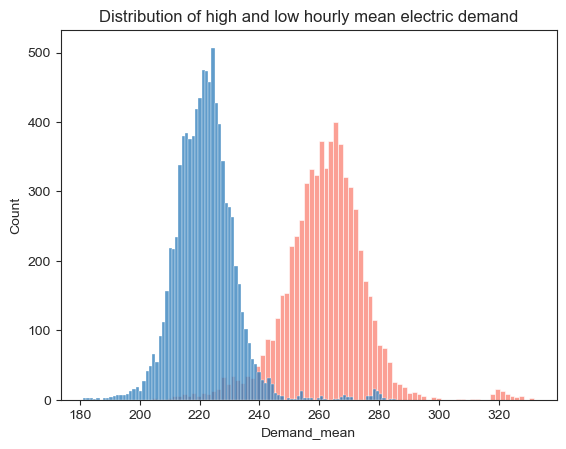

In [87]:
# Extract the high and low hourly mean electric demand
peak_demand_hours  = demand_train_f[(demand_train_f['Hour'] > 17)  & (demand_train_f['Hour'] < 20) & (demand_train_f['Weekday'] != 5)  & (demand_train_f['Weekday'] != 6)]
low_demand_hours = demand_train_f [(demand_train_f['Hour'] > 5)  & (demand_train_f['Hour'] < 8)]
_ = sns.histplot(peak_demand_hours['Demand_mean'], color="Salmon").set(title='Distribution of high and low hourly mean electric demand')
_ = sns.histplot(low_demand_hours['Demand_mean'], color="#2b7bba")

In [88]:
# Split test dataset and later populate with artificial anomalous dataset

def train_test_splitter (df):
    
    split = StratifiedShuffleSplit (n_splits=1, test_size = 0.2 , random_state=42)

    for train_index, test_index in split.split (df, df[['Hour', 'Month', 'Weekday']]):
        strat_train_set = df.iloc[train_index]
        strat_test_set = df.iloc[test_index]
        
          
    return strat_train_set, strat_test_set


# This is the same function used to split for the negative dataset. Also stratified using 'Hour', 'Month' and 'Weekday'
_ ,strat_anomalous_test_set = train_test_splitter (data)


# Positive test dataset split copy
positive_test = strat_anomalous_test_set.copy()

### Another option to generate Artificial Anomalous Dataset ###

In [89]:
# Generate and populate artifiical anomalous dataset - make it to a function

# df = demand_train.copy()

# A list of high demands - Feb has high demand
# demand_train_high = np.array(df[(df['Month'] == 2) & (df['Hour'] == 19) & (df['Weekday'] != 5) & (df['Weekday']!= 6)]['Demand_mean'].values)
# demand_train_high.sort ()
# demand_train_high = demand_train_high[demand_train_high > 250]
# _ = sns.histplot(demand_train_high,  color="Salmon")


# A list of low demands - Jun has low demand
# demand_train_low = np.array (df[(df['Month'] == 6) & (df['Weekday'] != 5) & (df['Weekday'] != 6)]['Demand_mean'].values)
# demand_train_low.sort()
# demand_train_low = demand_train_low[demand_train_low < 240]
# _ = sns.histplot(demand_train_low, color="#2b7bba")


# Populate anomalous dataset this is not based on a random demand from a distribution
# positive_test = positive_test.apply(gen_artificial_anomalous_2, args=(demand_train_high, demand_train_low), axis=1)
# positive_test = pd.DataFrame (positive_test)



In [90]:
# Show they are equally stratified by Hour, Month and Weekday
pd.DataFrame(positive_test['Weekday'].value_counts()/len(positive_test['Weekday'])).sort_index()

,Weekday
0,0.140668
1,0.141869
2,0.141869
3,0.150240
4,0.141505
5,0.141505
6,0.142342


In [91]:
def gen_artificial_anomalous (row):
    
    # find parameters of low-demand distribution
    # find parameters of high-demand distribution
    # if it's a weekday and hour >= 1 and hour <= 12 then generate 5 random numbers from the high-demand distribution 
    # if it's a weekday and hour > 12 and hour <= 23 then generate 5 random numbers from the low-demand distribution
    # if it's a weekend, then generate 5 random numbers from the high-demand distribution
    
    # high electric demand parameters
    c_high = 42.80
    d_high = 0.66
    loc_high = -1.16
    scale_high = 266.97
    
    # low electric demand parameters
    c_low = 42.53
    loc_low = -0.65
    scale_low = 222.14
    
    hour = int (row['Hour'])
    
    if ((hour >= 1 & hour <= 12)) | (hour >= 22) :
        # Note that the random_state is None so that we don't keep on generating the same random number
        demand = burr.rvs(c_high, d_high, loc=loc_high, scale=scale_high, size=5, random_state=None)
    
    elif (hour > 12 & hour) <= 21:
        demand = fisk.rvs(c_low, loc=loc_low, scale=scale_low, size=5, random_state=None)
    
    demand = np.around(demand,1)
    
    row ['Demand_0'] = demand [0]
    row ['Demand_15'] = demand [1]
    row ['Demand_30'] = demand [2]
    row ['Demand_45'] = demand [3]
    row ['Demand_60'] = demand [4]
    
    return row

positive_test_backup = positive_test.apply(gen_artificial_anomalous, axis=1)
positive_test_backup = positive_test_backup.astype({"Hour": int, "Month": int, "Weekday": int, "Minute": int})

In [92]:
positive_test = positive_test_backup.copy()

In [93]:
positive_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 27476 entries, 20143 to 24696
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Hour           27476 non-null  int64  
 1   Minute         27476 non-null  int64  
 2   Temperature    27476 non-null  float64
 3   DewPoint       27476 non-null  float64
 4   Humidity       27476 non-null  float64
 5   WindSpeed      27476 non-null  float64
 6   WindGust       27476 non-null  float64
 7   Pressure       27476 non-null  float64
 8   Precipitation  27476 non-null  float64
 9   Month          27476 non-null  int64  
 10  Weekday        27476 non-null  int64  
 11  Demand_0       27476 non-null  float64
 12  Demand_15      27476 non-null  float64
 13  Demand_30      27476 non-null  float64
 14  Demand_45      27476 non-null  float64
 15  Demand_60      27476 non-null  float64
dtypes: float64(12), int64(4)
memory usage: 3.6 MB


### Comparing Distributions ###

Now let's check if the distribution we fit to the high and low hourly mean demand is correct. We will generate random demand values using the parameters (for both high and low) and compare them to the values we selected using the hour filter using Kolmogorov-Smirnov two-sample test.

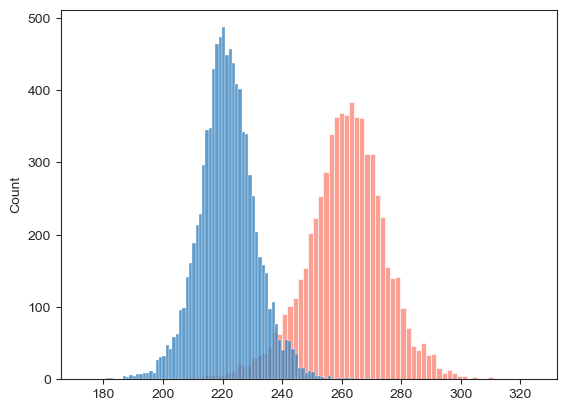

In [94]:
c_high = 42.80
d_high = 0.66
loc_high = -1.16
scale_high = 266.97

r_high = burr.rvs (c_high, d_high, loc_high, scale_high, size=6472, random_state=24)
_ = sns.histplot(r_high, color='Salmon')

c_low = 42.53
loc_low = -0.65
scale_low = 222.14

r_low = fisk.rvs(c_low, loc=loc_low, scale=scale_low, size=9053, random_state=24)
_ = sns.histplot (r_low, color="#2b7bba")

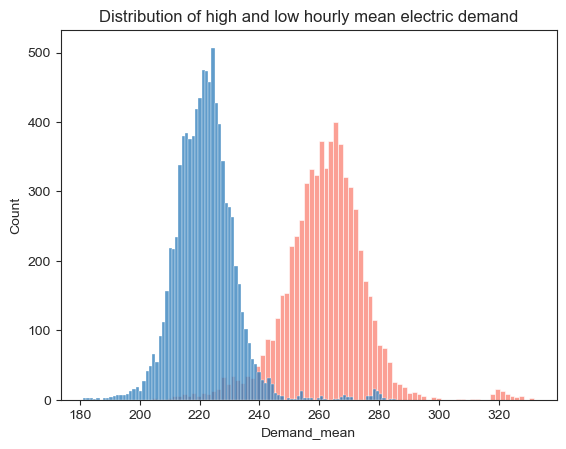

In [95]:
# Extract the high and low hourly mean electric demand
# Repeated for clarity
peak_demand_hours  = demand_train_f[(demand_train_f['Hour'] > 17)  & (demand_train_f['Hour'] < 20) & (demand_train_f['Weekday'] != 5)  & (demand_train_f['Weekday'] != 6)]
low_demand_hours = demand_train_f [(demand_train_f['Hour'] > 5)  & (demand_train_f['Hour'] < 8)]
_ = sns.histplot(peak_demand_hours['Demand_mean'], color="Salmon").set(title='Distribution of high and low hourly mean electric demand')
_ = sns.histplot(low_demand_hours['Demand_mean'], color="#2b7bba")

#### Verify Sampling Distribution for Anomalous Artificial Dataset ####

In [96]:
sp.stats.ks_2samp(r_low, low_demand_hours ['Demand_mean'].values, alternative='two-sided', mode='auto')

KstestResult(statistic=0.018651393591133606, pvalue=0.08420378697886238)

In [97]:
sp.stats.ks_2samp(r_high, peak_demand_hours ['Demand_mean'].values, alternative='two-sided', mode='auto') 

KstestResult(statistic=0.021168108776266997, pvalue=0.11002557818255458)

##### The pvalues of both tests is greater than 0.05, hence we can't reject the null hypothesis which states that the two distributions are identical. ##### 

## Exploratory Data Analysis ##

Now that we have split our training and test datasets, let's perform some exploratory data analysis of the training dataset.

The portal had demand dataset available from Jan 2015-June 2021. However, the dataset used in the modelling process is from Jan 2016 - Dec 2019. The reason this sample was selected is on the first hand, an observation of the annual demand shows that the facility had higher electric demand in 2015 compared to the following 6 years. There could be various reasons for this fall in demand: building or equipment renovation could be one example, or changes to the number of smart meters could be another. In any case, I believe that the electric demand for the year 2015 may not represent the current demand appetite of the building. Also, most probably because of the global pandemic related lockdown, there was a sudden fall in the demand after April 2020. For this reason, the dataset selected for this modelling exercise is from Jan 2016 - Dec 2019.

Similar to the previous paper, the key assumption made here is that the building behaves predominantly normal. The main reason behind this assumption is the lack of labeled dataset. To test the sensitivity of the models, an artificial anomaly dataset has been prepared and part of the dataset has also been set aside to test the specificity of the models.  

## Hourly mean demand distribution ##

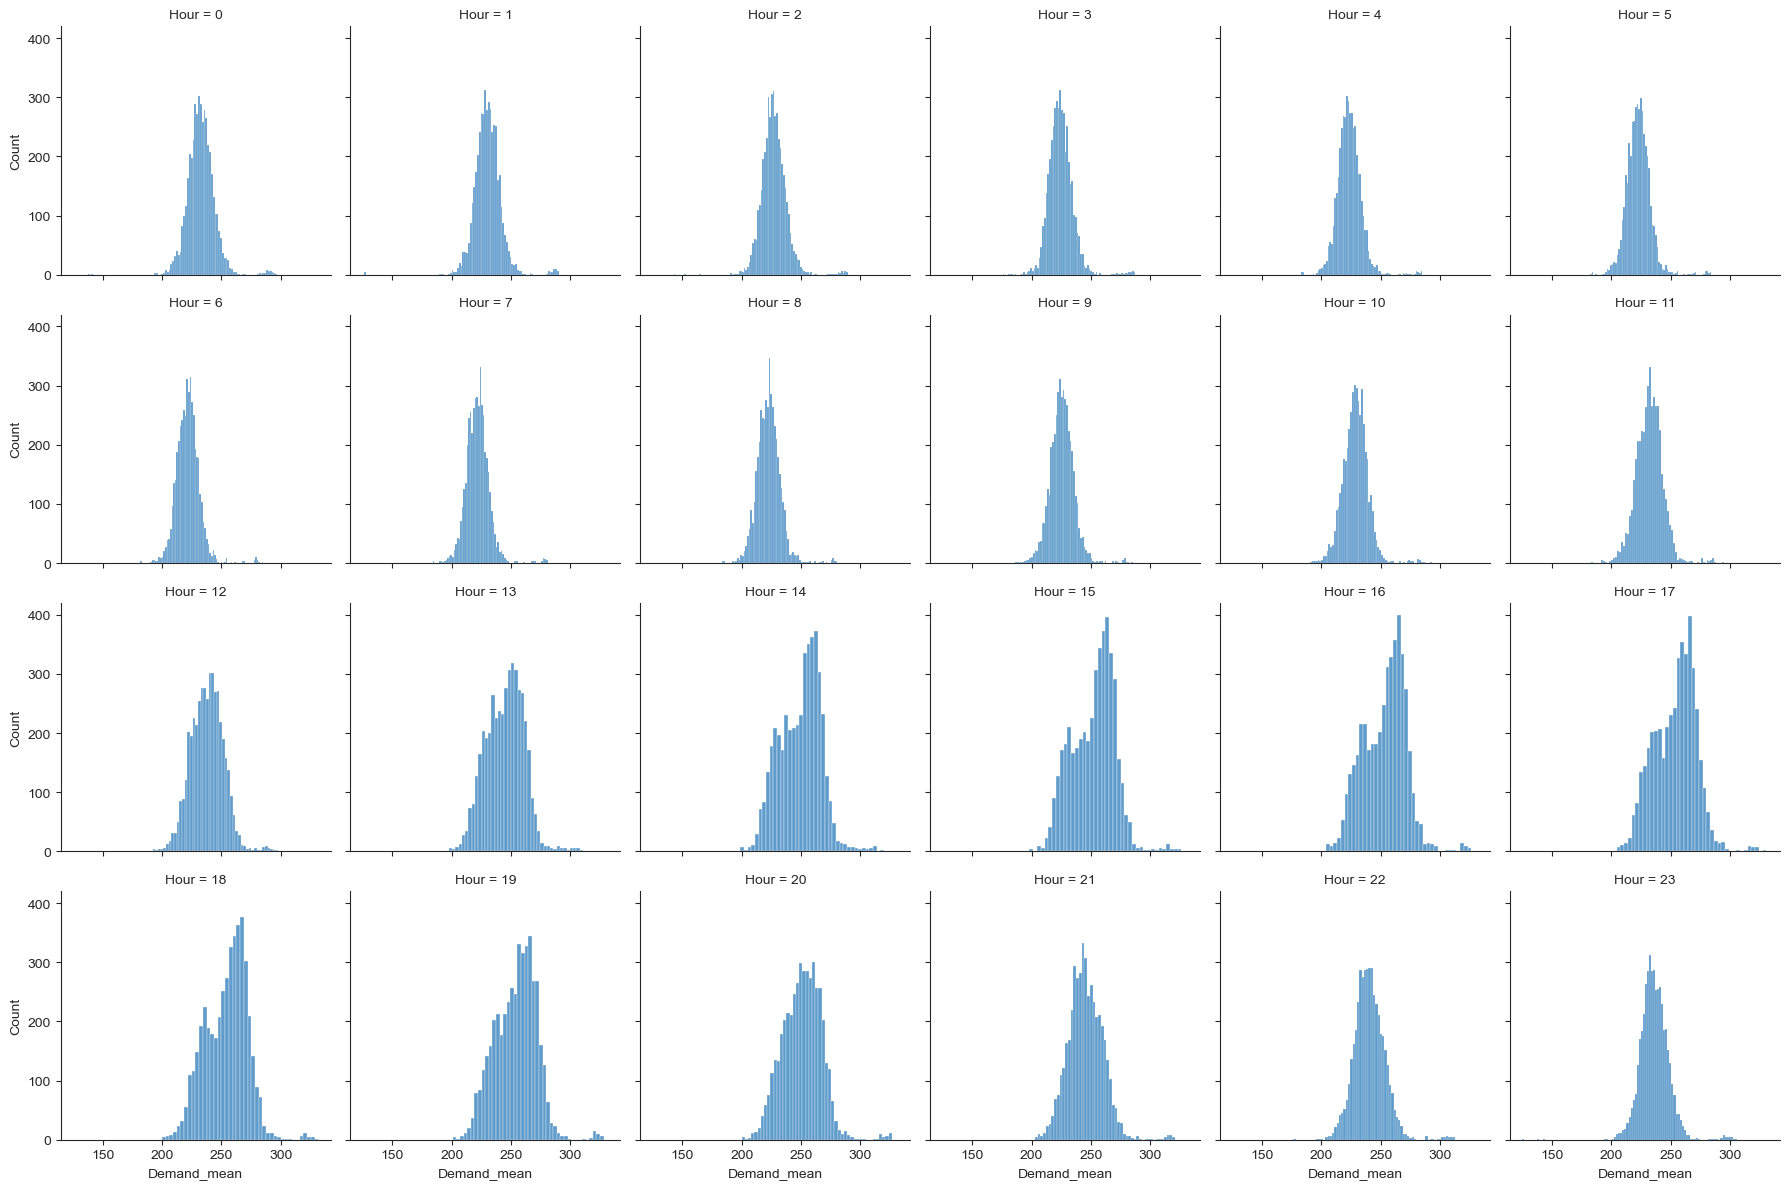

In [98]:
g = sns.FacetGrid(new_demand, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

The hourly mean demand distributions seem for the most part normally distributed, note that these hourly distributions include both weekday and weekend demand values, hence the distributions for some of the hours have slightly fatter left tail end.

## Hourly mean demand distribution - Weekday ##

In [99]:
weekday_index = demand_train_f.index[~((demand_train_f['Weekday'] == 5) | (demand_train_f['Weekday'] == 6))]
weekend_index = demand_train_f.index[((demand_train_f['Weekday'] == 5) | (demand_train_f['Weekday'] == 6))]
demand_weekday = demand_train_f.iloc[weekday_index]
demand_weekend = demand_train_f.iloc[weekend_index]

new_demand_weekday = demand_weekday.reset_index(drop=True)
new_demand_weekend = demand_weekend.reset_index(drop=True)

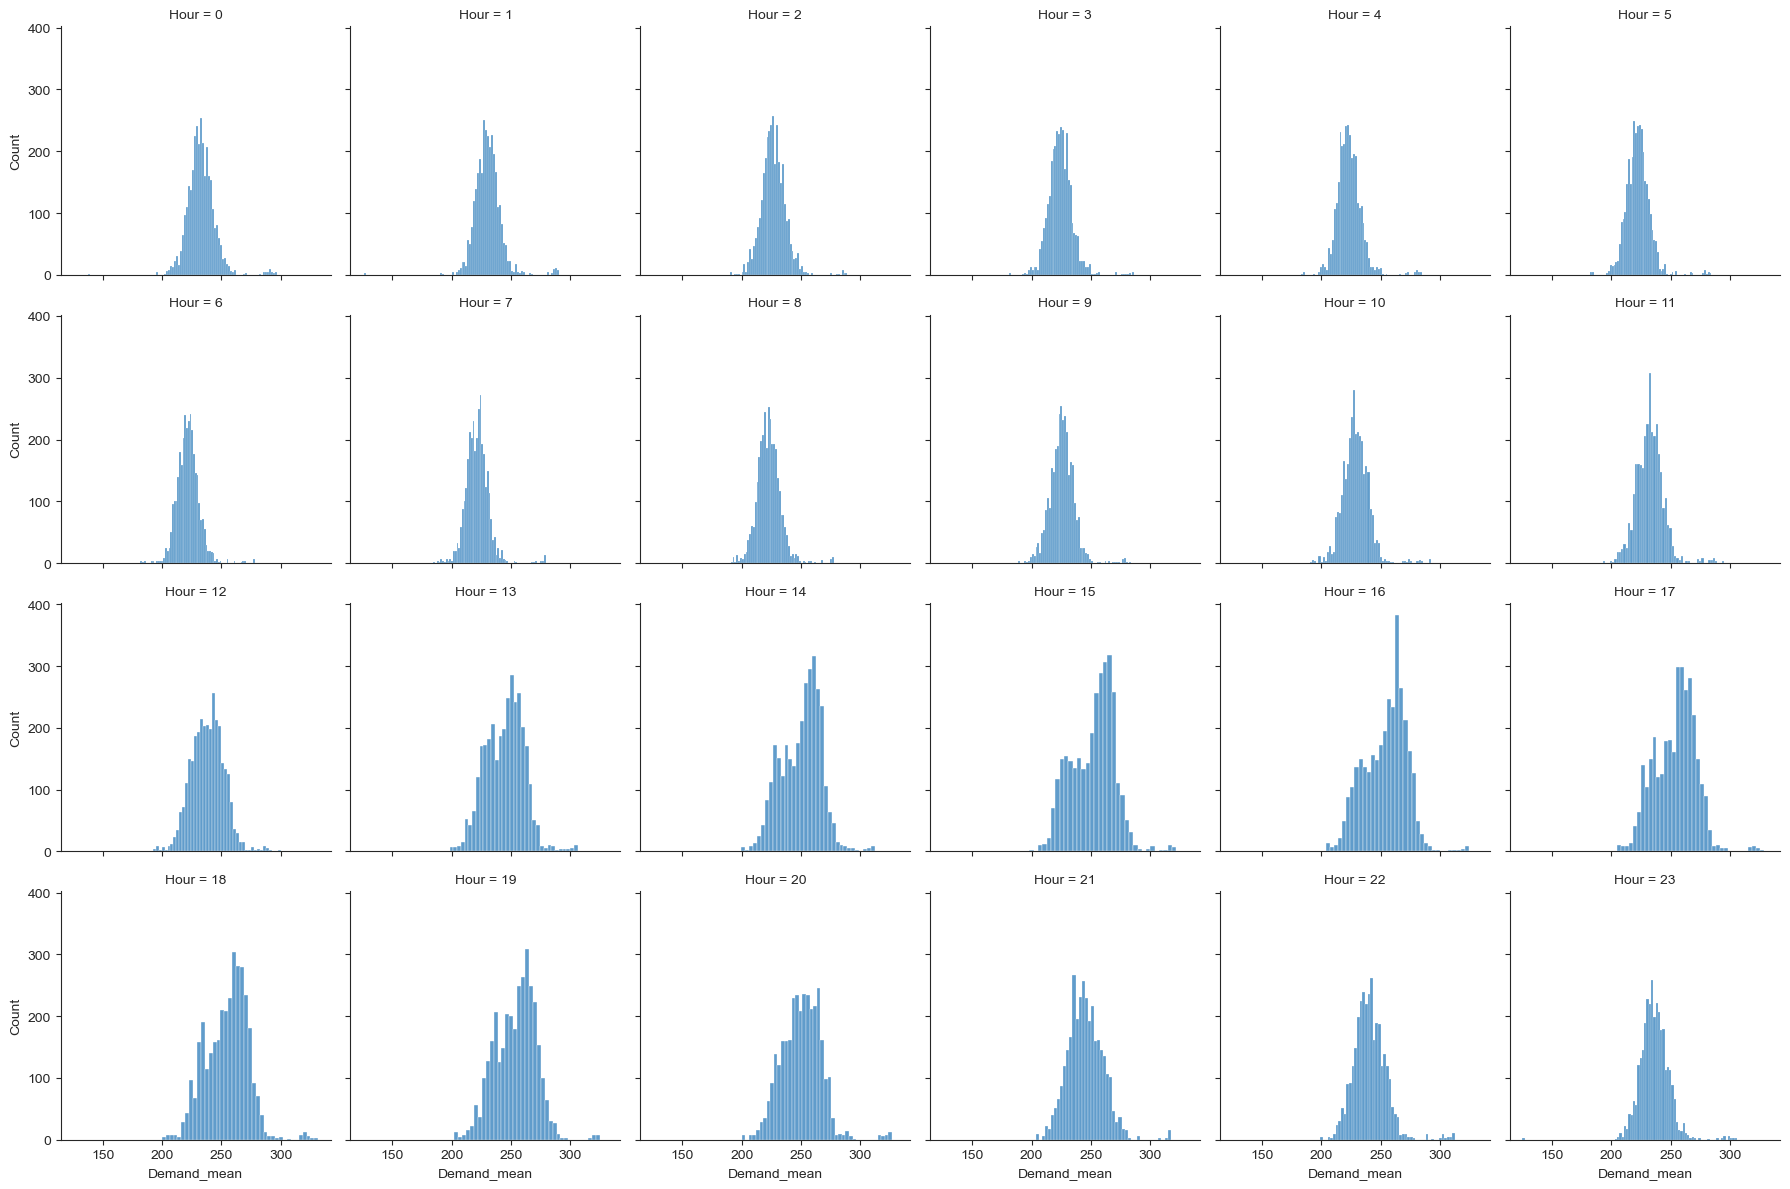

In [100]:
g = sns.FacetGrid(new_demand_weekday, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

## Hourly mean demand distribution - Weekend ##

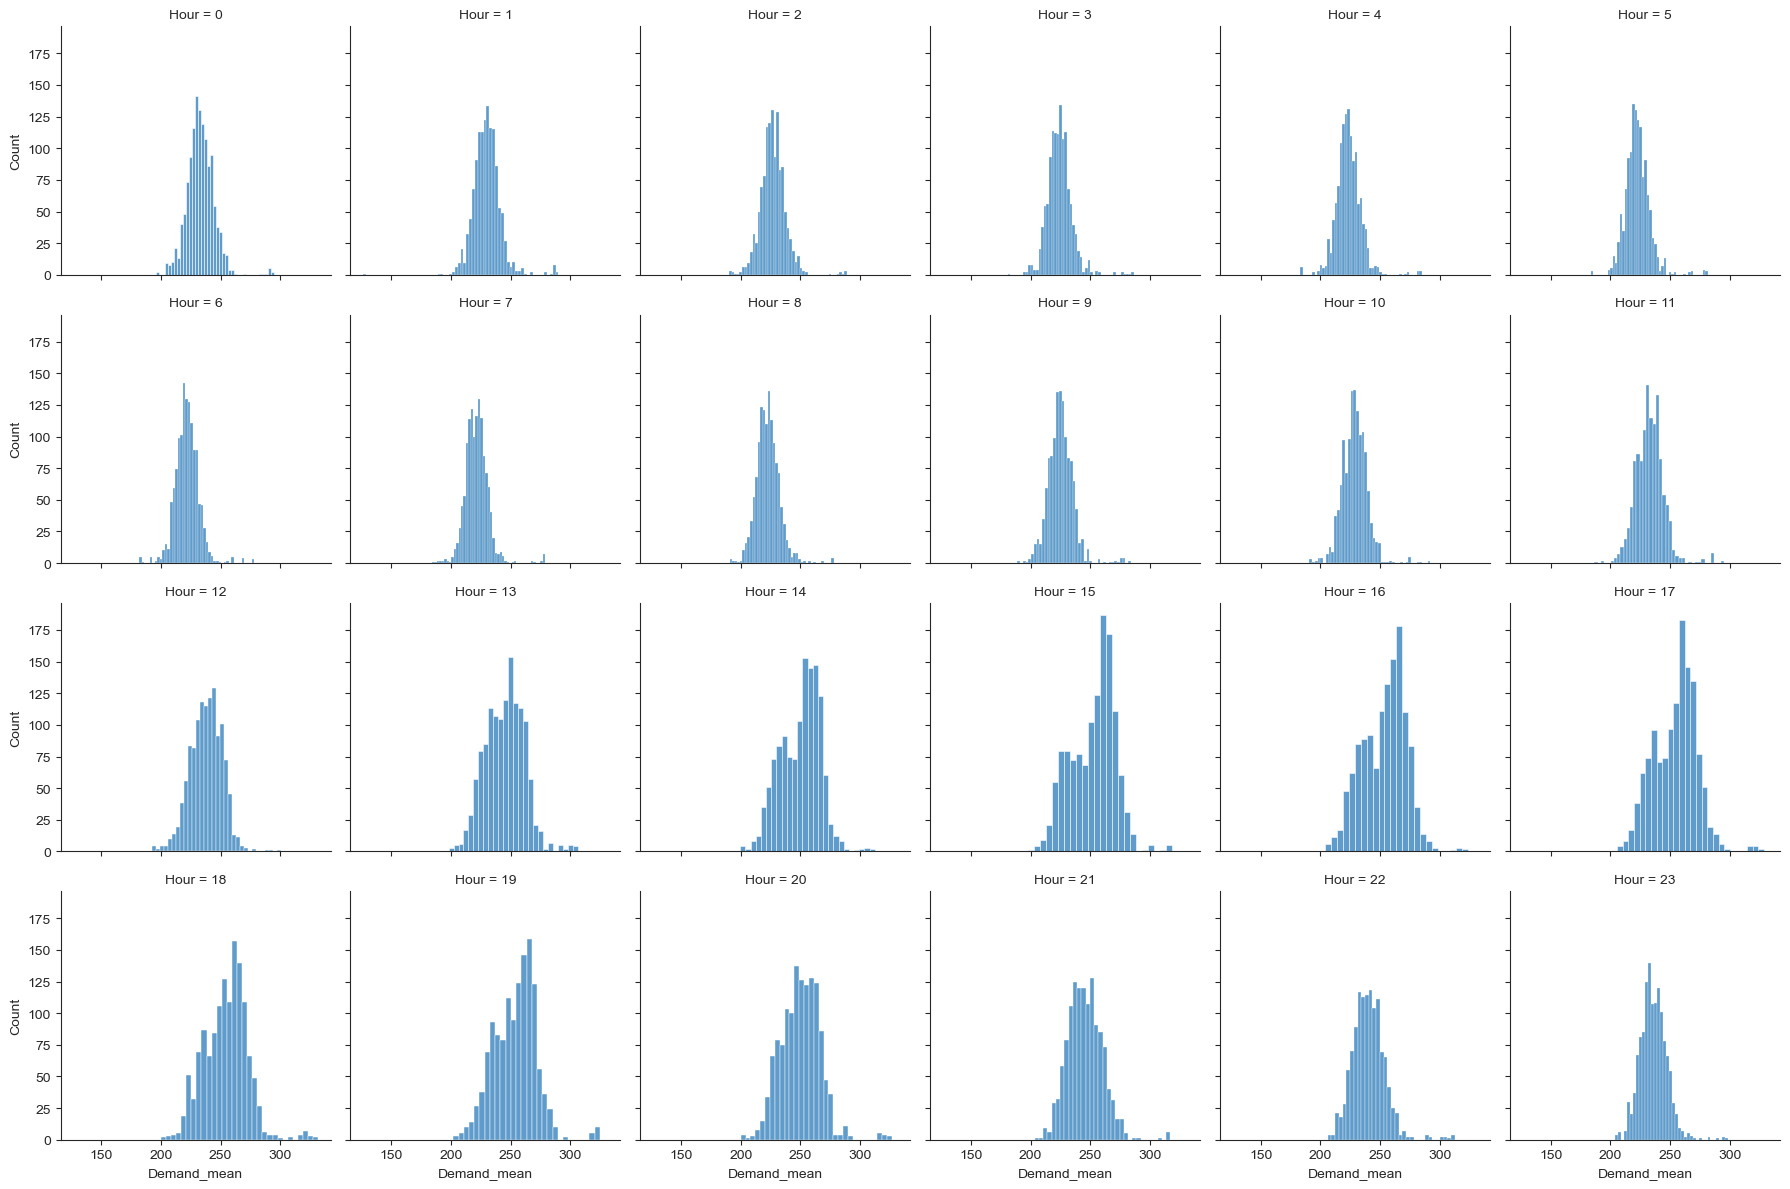

In [103]:
g = sns.FacetGrid(new_demand_weekend, col="Hour", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

## Day of week mean demand distribution ##
###### Week 6: Sunday ######

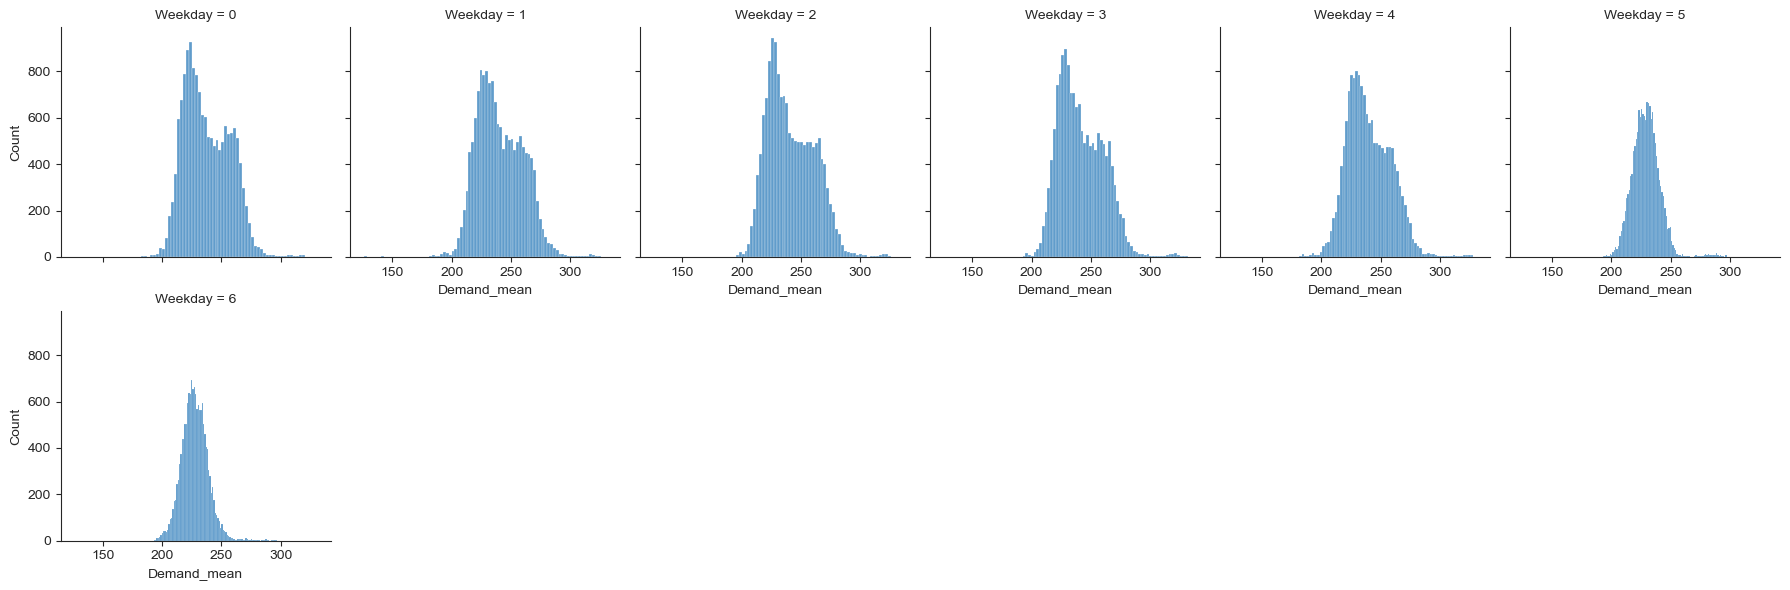

In [104]:
g = sns.FacetGrid(new_demand, col="Weekday", height=3, col_wrap=6)
_ = g.map_dataframe(sns.histplot, x="Demand_mean", color="#2b7bba")

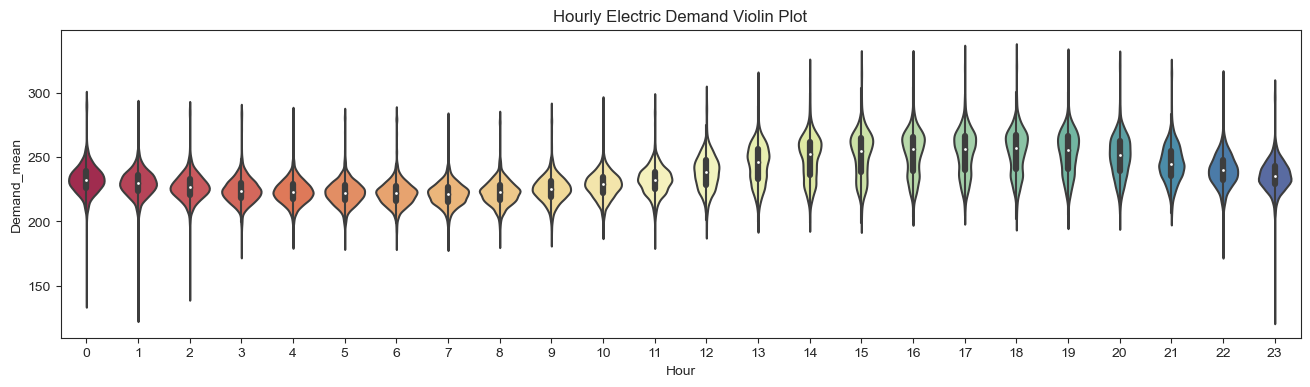

In [105]:
fig, ax = plt.subplots(figsize = (16, 4))
ax = sns.violinplot(x='Hour', y='Demand_mean', data=new_demand, palette="Spectral").set(title='Hourly Electric Demand Violin Plot')

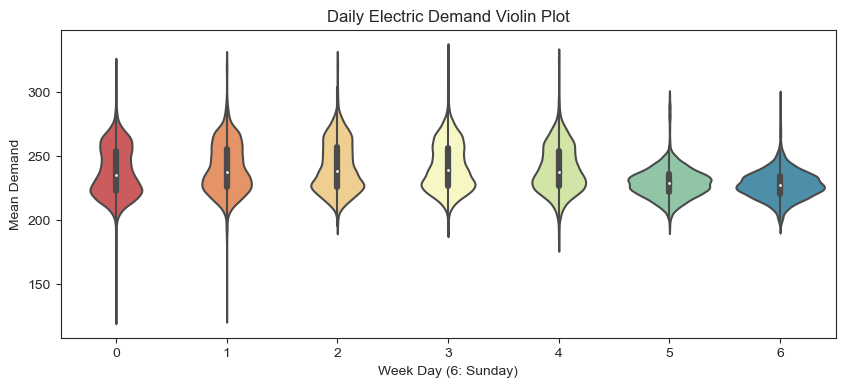

In [106]:
fig, ax = plt.subplots(figsize = (10, 4))
ax = sns.violinplot(x='Weekday', y='Demand_mean', data=new_demand,  palette="Spectral")
_ = ax.set (xlabel="Week Day (6: Sunday)", ylabel="Mean Demand", title='Daily Electric Demand Violin Plot')

### Univariate Analysis ###

In [107]:
correlation = demand_train_f.corr()['Demand_mean'].sort_values(ascending=False)
correlation

Demand_mean      1.000000
Demand_30        0.971272
Demand_45        0.968345
Demand_15        0.968053
Demand_60        0.958895
Demand_0         0.958840
Hour             0.491231
Demand_sd        0.193687
WindSpeed        0.102666
Temperature      0.078221
WindGust         0.050717
Pressure         0.014430
Precipitation    0.009482
Minute          -0.000704
DewPoint        -0.018668
Month           -0.044114
Weekday         -0.214036
Humidity        -0.257697
Name: Demand_mean, dtype: float64

As we expected, 'Hour' is strongly correlated to the mean hourly demand (0.5). Moreover, 'Humidity' and 'Weekday' also show significant correlation. Note that this is only a measure of linear correlation - it doesn't capture non-linear correlation.

### Multivariate Analysis ###

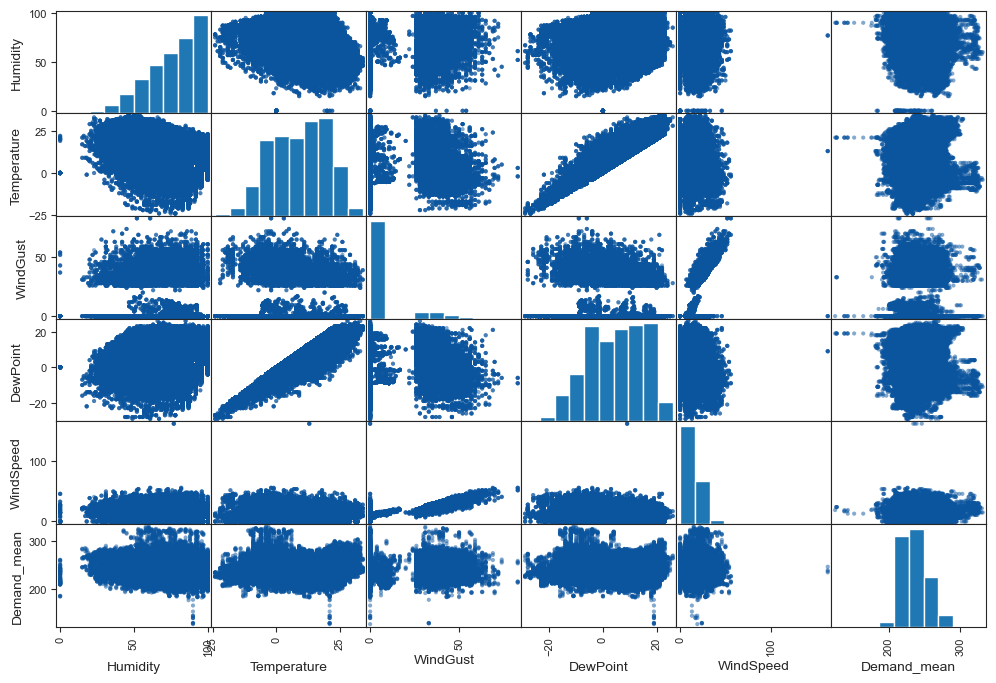

In [108]:
attributes_weather = ['Humidity', 'Temperature', 'WindGust', 'DewPoint', 'WindSpeed', 'Demand_mean']
attributes_temporal = ['Hour', 'Minute', 'Weekday', 'Month', 'Demand_mean']

_ = scatter_matrix(new_demand[attributes_weather], figsize=(12,8), color="#0b559f")

Temperature and Dewpoint are highly correlated, also, Windspeed and Windgust are highly correlated

## Data Transformation ##

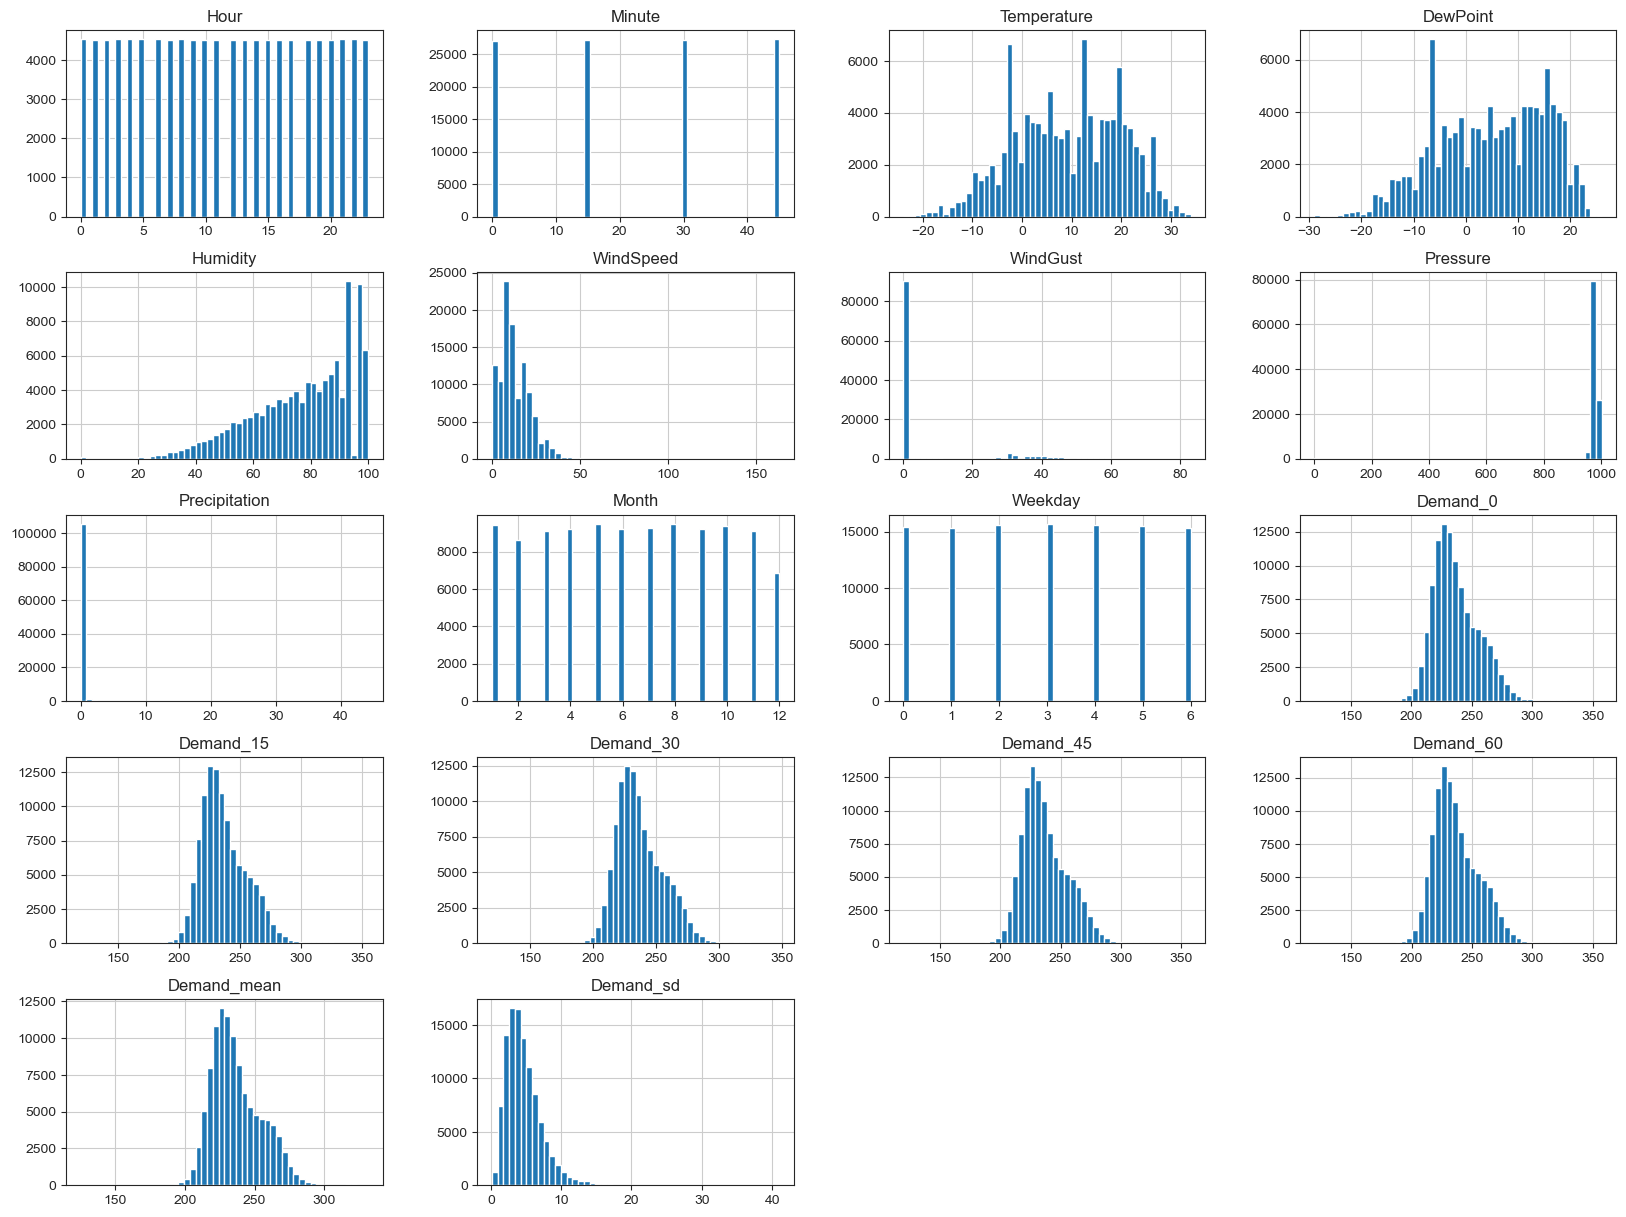

In [109]:
_ = demand_train_f.hist(bins=50, figsize=(20,15))

In [110]:
def transform_drivers (df, drivers):
    df_new = df.copy()
    for d in drivers:
        df_new[d] = Quantile_transform (df_new[d])
    return df_new

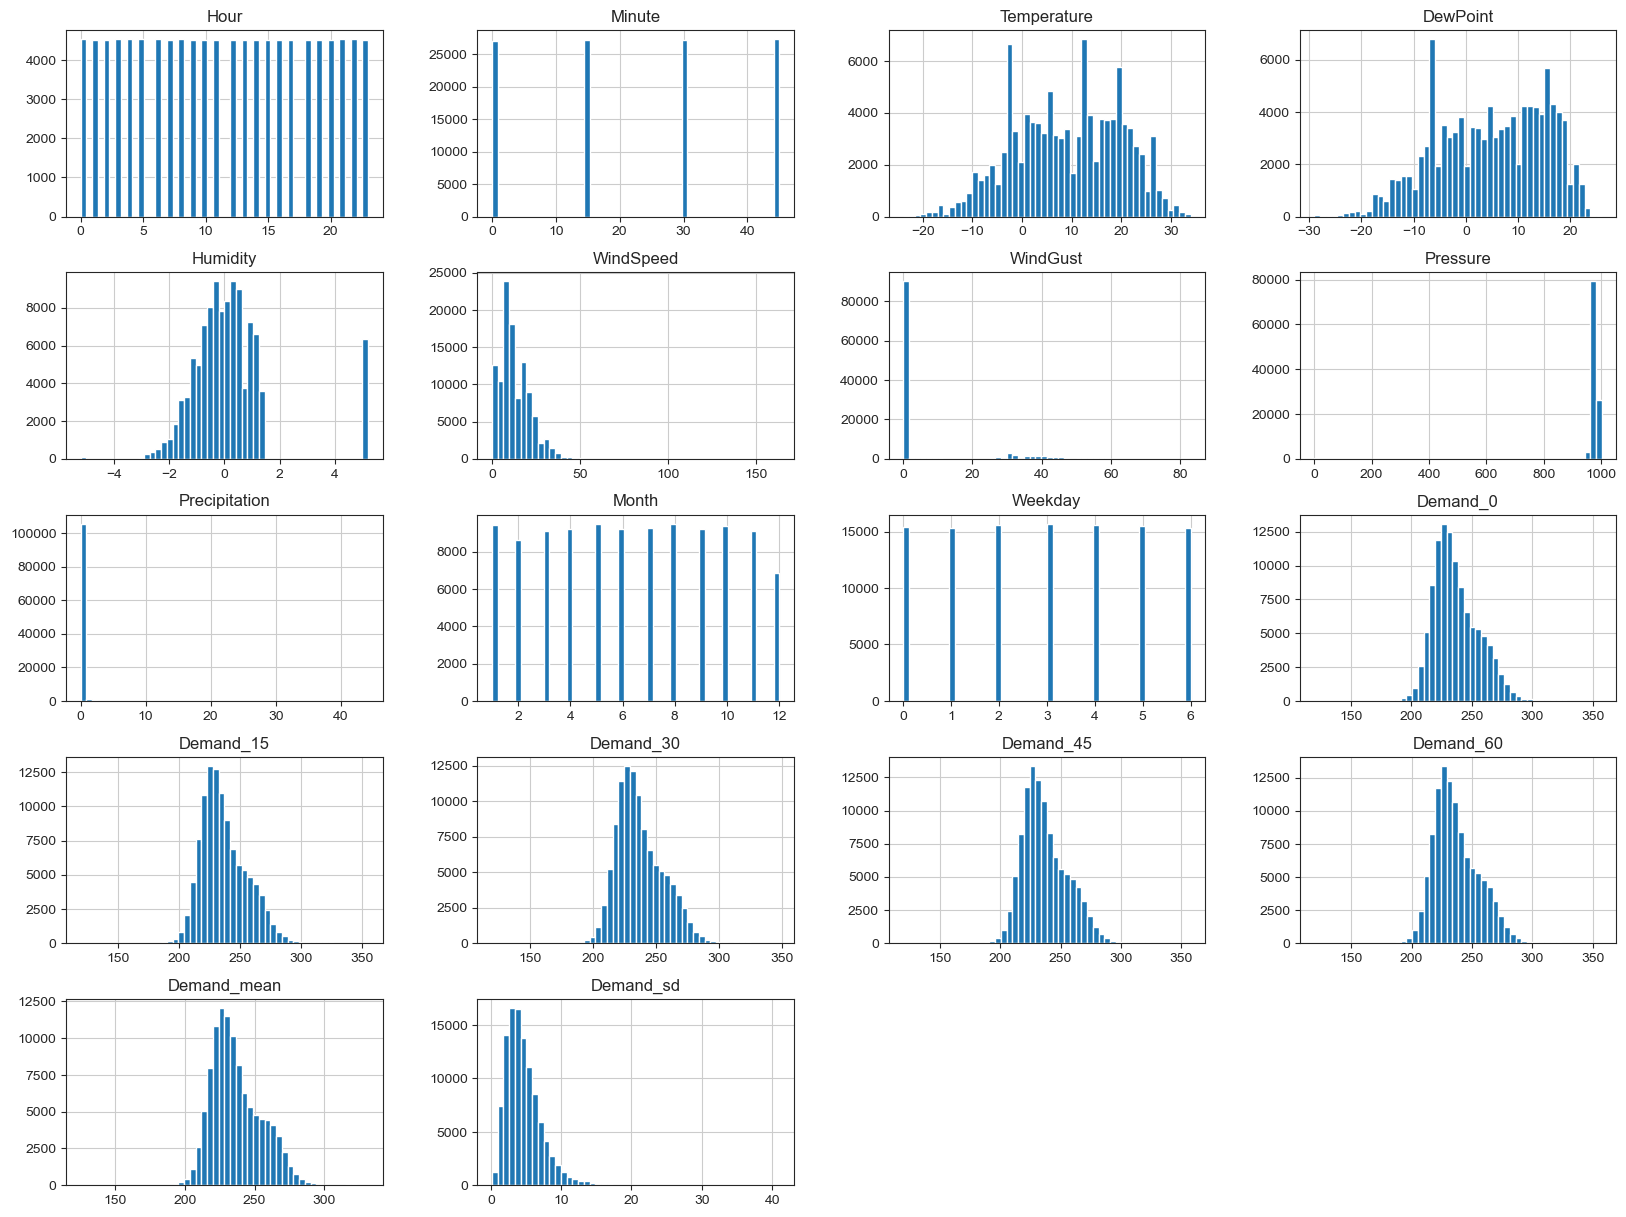

In [111]:
drivers = ['Humidity']
demand_train_ft = transform_drivers (new_demand, drivers)   
_ = demand_train_ft.hist(bins=50, figsize=(20,15))

In [112]:
demand_train_ft.agg(['skew', 'kurtosis']).transpose()

,skew,kurtosis
Hour,0.000815,-1.205635
Minute,-0.003975,-1.360504
Temperature,-0.155510,-0.756447
DewPoint,-0.279931,-0.833464
Humidity,1.781550,4.443451
WindSpeed,0.912528,3.829755
WindGust,2.110926,2.976069
Pressure,-24.542815,622.339572
Precipitation,21.953098,790.585541
Month,-0.000235,-1.188466


 ### Temporal features Data Encoding ###

The temporal features 'Hour', 'Weekday' and 'Month' are categorical, however, encoding them using dummies would not take the fact that these attributes are cyclic in nature. For instance, it would not take into account the fact that December is closer to January than September or 1 am is closer to 11 pm than to 4 am or Monday is closer to Sunday than to Wednesday. To account for this cyclic nature of the features, each value will be represented as a point in a circle using an x and y component.

In [113]:
def temporal_feature_cyclic (data):
    
    minutes_in_hour = 60
    hours_in_day = 24
    days_in_week = 7
    months_in_year = 12
    
    df = data.copy()
    
    df['sin_minutes'] = np.sin(2*np.pi*df['Minute']/minutes_in_hour)
    df['cos_minutes'] = np.cos(2*np.pi*df['Minute']/minutes_in_hour)
    
    df['sin_hours'] = np.sin(2*np.pi*df['Hour']/hours_in_day)
    df['cos_hours'] = np.cos(2*np.pi*df['Hour']/hours_in_day)
    
    df['sin_days'] = np.sin(2*np.pi*df['Weekday']/days_in_week)
    df['cos_days'] = np.cos(2*np.pi*df['Weekday']/days_in_week)
    
    df['sin_months'] = np.sin(2*np.pi*df['Month']/months_in_year)
    df['cos_months'] = np.cos(2*np.pi*df['Month']/months_in_year)
    
    

    #df.drop(['Hour', 'Weekday', 'Month'], axis=1, inplace=True)
    
    return (df)

In [114]:
demand_train_backup = new_demand.copy()

In [115]:
demand_train_ft_c = temporal_feature_cyclic (demand_train_ft)

In [116]:
demand_train_ft_c.head()

,Hour,Minute,Temperature,DewPoint,Humidity,WindSpeed,WindGust,Pressure,Precipitation,Month,...,Demand_mean,Demand_sd,sin_minutes,cos_minutes,sin_hours,cos_hours,sin_days,cos_days,sin_months,cos_months
0,21,15,17.0,11.0,-0.564267,9.0,0.0,980.42,0.0,8,...,229.60,7.402702,1.0,2.832769e-16,-0.707107,0.707107,0.000000,1.000000,-0.866025,-5.000000e-01
1,11,15,-7.0,-14.0,-0.993800,0.0,0.0,989.53,0.0,1,...,219.06,5.223313,1.0,2.832769e-16,0.258819,-0.965926,-0.781831,0.623490,0.500000,8.660254e-01
2,2,15,22.0,22.0,5.199338,9.0,0.0,973.26,0.0,7,...,238.14,1.718430,1.0,2.832769e-16,0.500000,0.866025,-0.433884,-0.900969,-0.500000,-8.660254e-01
3,16,15,11.0,-2.0,-1.811457,11.0,0.0,976.19,0.0,4,...,264.40,2.205675,1.0,2.832769e-16,-0.866025,-0.500000,0.433884,-0.900969,0.866025,-5.000000e-01
4,7,0,-4.0,-8.0,-0.124523,15.0,0.0,982.05,0.0,3,...,228.62,1.580190,0.0,1.000000e+00,0.965926,-0.258819,0.000000,1.000000,1.000000,6.123234e-17


In [117]:
demand_train_ft_c.corr()['Demand_mean'].sort_values(ascending=False)

Demand_mean      1.000000
Demand_30        0.971272
Demand_45        0.968345
Demand_15        0.968053
Demand_60        0.958895
Demand_0         0.958840
Hour             0.491231
sin_days         0.253020
Demand_sd        0.193687
WindSpeed        0.102666
Temperature      0.078221
WindGust         0.050717
sin_months       0.046563
cos_months       0.028793
Pressure         0.014430
Precipitation    0.009482
cos_minutes      0.001195
sin_minutes      0.000008
Minute          -0.000704
DewPoint        -0.018668
Month           -0.044114
cos_days        -0.098510
cos_hours       -0.099613
Weekday         -0.214036
Humidity        -0.222020
sin_hours       -0.645192
Name: Demand_mean, dtype: float64

The newly generated feature sin_hours is significantly more correlated to the mean hourly demand than the hour, moreover, the sin_days is also more correlated than Weeekdays. Pretty good! 

In [118]:
demand_train_ft_c.columns

Index(['Hour', 'Minute', 'Temperature', 'DewPoint', 'Humidity', 'WindSpeed',
       'WindGust', 'Pressure', 'Precipitation', 'Month', 'Weekday', 'Demand_0',
       'Demand_15', 'Demand_30', 'Demand_45', 'Demand_60', 'Demand_mean',
       'Demand_sd', 'sin_minutes', 'cos_minutes', 'sin_hours', 'cos_hours',
       'sin_days', 'cos_days', 'sin_months', 'cos_months'],
      dtype='object')

In [119]:
demand_train_ft_c.drop(['Minute', 'Hour', 'Weekday', 'Month'], axis=1, inplace=True)

**The temporal feature 'Minute' is categorical. Let's convert it into dummy variables**

In [120]:
demand_train_ft_c.columns

Index(['Temperature', 'DewPoint', 'Humidity', 'WindSpeed', 'WindGust',
       'Pressure', 'Precipitation', 'Demand_0', 'Demand_15', 'Demand_30',
       'Demand_45', 'Demand_60', 'Demand_mean', 'Demand_sd', 'sin_minutes',
       'cos_minutes', 'sin_hours', 'cos_hours', 'sin_days', 'cos_days',
       'sin_months', 'cos_months'],
      dtype='object')

In [121]:
features_autoencoder = ['Demand_0', 'Demand_15', 'Demand_30',
       'Demand_45', 'Demand_60', 'Demand_mean', 'Demand_sd', 'sin_hours',
       'cos_hours', 'sin_days', 'cos_days', 'sin_months', 'cos_months',
       'sin_minutes', 'cos_minutes', 'Humidity']

demand_train_autoencoder_t = demand_train_ft_c.copy ()

demand_train_autoencoder_t = demand_train_autoencoder_t [features_autoencoder]

In [122]:
demand_train_autoencoder_t.head()

,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Demand_mean,Demand_sd,sin_hours,cos_hours,sin_days,cos_days,sin_months,cos_months,sin_minutes,cos_minutes,Humidity
0,237.9,235.0,219.1,226.3,229.7,229.60,7.402702,-0.707107,0.707107,0.000000,1.000000,-0.866025,-5.000000e-01,1.0,2.832769e-16,-0.564267
1,224.9,223.3,212.0,216.4,218.7,219.06,5.223313,0.258819,-0.965926,-0.781831,0.623490,0.500000,8.660254e-01,1.0,2.832769e-16,-0.993800
2,238.6,236.0,236.7,239.5,239.9,238.14,1.718430,0.500000,0.866025,-0.433884,-0.900969,-0.500000,-8.660254e-01,1.0,2.832769e-16,5.199338
3,263.0,264.8,263.0,263.1,268.1,264.40,2.205675,-0.866025,-0.500000,0.433884,-0.900969,0.866025,-5.000000e-01,1.0,2.832769e-16,-1.811457
4,228.6,231.2,228.1,228.3,226.9,228.62,1.580190,0.965926,-0.258819,0.000000,1.000000,1.000000,6.123234e-17,0.0,1.000000e+00,-0.124523


# Feature Scaling #

Discuss why we need feature scaling - use pipelines

In [123]:
scaler = StandardScaler ()

# scaler for autoencoder features
scaler_autoencoder = StandardScaler ()

# demand_train_t = scaler.fit_transform(demand_train_t)
demand_train_t_autoencoder = scaler_autoencoder.fit_transform (demand_train_autoencoder_t)

## Test Dataset Treatment ##

In [134]:
# Treat missing data for both positive and negative test dataset
positive_test = missing_treatment (positive_test)
negative_test = missing_treatment (negative_test)

In [135]:
# generate new features for the positive and negative test datasets
positive_test = generate_features (positive_test)
negative_test = generate_features (negative_test)

In [136]:
drivers = ['Humidity']
negative_test_t = transform_drivers (negative_test, drivers)  
positive_test_t = transform_drivers (positive_test, drivers)

In [137]:
# Encode the feature 'Minute' using dummy variables
# **************** not encode minutes *****************
negative_test_t_e = temporal_feature_cyclic (negative_test_t)
positive_test_t_e = temporal_feature_cyclic (positive_test_t)


negative_test_t_e_d = pd.get_dummies(negative_test_t_e, columns=['Minute'])
positive_test_t_e_d = pd.get_dummies (positive_test_t_e, columns=['Minute'])


In [138]:
positive_test_autoencoder = positive_test_t_e_d[features_autoencoder]
negative_test_autoencoder = negative_test_t_e_d[features_autoencoder]

In [139]:
negative_test_autoencoder.head()

,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Demand_mean,Demand_sd,sin_hours,cos_hours,sin_days,cos_days,sin_months,cos_months,sin_minutes,cos_minutes,Humidity
20143,215.6,222.6,214.3,216.7,211.9,216.22,3.989612,-0.965926,0.258819,-0.974928,-0.222521,-0.500000,-0.866025,-1.0,-1.836970e-16,-1.994971
10071,243.7,245.8,239.0,240.4,233.8,240.54,4.622553,-0.707107,0.707107,0.000000,1.000000,0.866025,-0.500000,-1.0,-1.836970e-16,0.622621
12765,231.1,238.2,237.8,235.8,236.7,235.92,2.854295,-0.258819,0.965926,0.433884,-0.900969,0.500000,-0.866025,1.0,2.832769e-16,-0.119468
20239,221.7,229.3,234.2,234.9,220.1,228.04,6.888977,-0.965926,0.258819,-0.781831,0.623490,-0.500000,-0.866025,-1.0,-1.836970e-16,0.179102
19460,274.7,270.8,269.1,270.1,285.9,274.12,6.918959,-0.965926,-0.258819,0.433884,-0.900969,-0.500000,-0.866025,0.0,1.000000e+00,-1.100140


In [140]:
# negative_test_t = scaler.transform (negative_test_t)
# positive_test_t = scaler.transform (positive_test_t)

negative_test_autoencoder = scaler_autoencoder.transform (negative_test_autoencoder)
positive_test_autoencoder = scaler_autoencoder.transform (positive_test_autoencoder)

# Model Training #

# Algorithms used in this project #
##### 1. Deep Learning Autoencoder #####
##### 2. Support Vector Regression #####
##### 3. Random Forest             #####
##### 4. Gradient boosting algorithm and AdaBoosting algorithm                   #####
##### 5. Linear regression #####
##### 6. Decision tree #####
##### 7. K-means #####
##### 8. Naive Bayes algorithm #####
##### 9. KNN #####
##### #####
##### #####
##### #####
##### #####
##### #####

In [142]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321 . connected.


H2O_cluster_uptime:,48 mins 49 secs
H2O_cluster_timezone:,America/Toronto
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.30.0.4
H2O_cluster_version_age:,"2 years, 2 months and 18 days !!!"
H2O_cluster_name:,H2O_from_python_daniel_uwxqoc
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.542 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


In [146]:
demand_train_h2o = h2o.H2OFrame(demand_train_t_autoencoder)
negative_test_h2o = h2o.H2OFrame (negative_test_t_e_d)
positive_test_h2o = h2o.H2OFrame (positive_test_t_e_d)

Parse progress: |█████████████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%


In [147]:
demand_train_t_autoencoder_h2o = h2o.H2OFrame (demand_train_t_autoencoder)
negative_test_autoencoder_h2o = h2o.H2OFrame (negative_test_autoencoder)
positive_test_autoencoder_h2o = h2o.H2OFrame (positive_test_autoencoder)

Parse progress: |█████████████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%
Parse progress: |█████████████████████████████████████████████████████████| 100%


In [148]:
features = demand_train_t_autoencoder_h2o.columns

anomaly_model = H2OAutoEncoderEstimator(activation = "Tanh",
                               hidden = [25,14, 6],
                               epochs = 200,
                               standardize = True,
                                stopping_metric = 'MSE', 
                                loss = 'automatic',
    
                                shuffle_training_data = True,     
                               autoencoder = True,
                               l1 = 10e-5)
anomaly_model.train(x=features, training_frame = demand_train_t_autoencoder_h2o)

deeplearning Model Build progress: |██████████████████████████████████████| 100%


In [149]:
negative_test_rec_error=anomaly_model.anomaly (negative_test_autoencoder_h2o)
positive_test_rec_error=anomaly_model.anomaly (positive_test_autoencoder_h2o)
train_rec_error = anomaly_model.anomaly (demand_train_t_autoencoder_h2o)

In [150]:
negative_mse = negative_test_rec_error.as_data_frame()
positive_mse = positive_test_rec_error.as_data_frame()
train_mse = train_rec_error.as_data_frame()

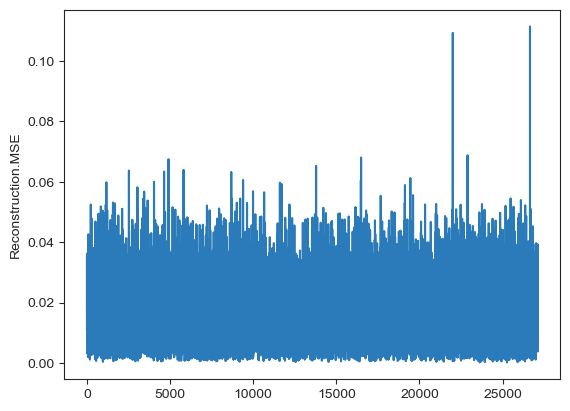

In [151]:
_ = sns.lineplot (x=negative_mse.index, y=negative_mse['Reconstruction.MSE'], color="#2b7bba")

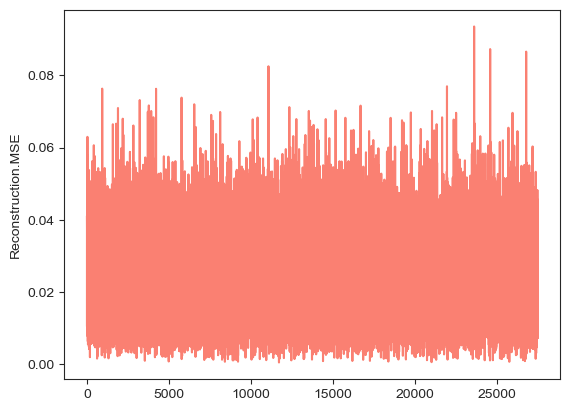

In [152]:
_ = sns.lineplot (x=positive_mse.index, y=positive_mse['Reconstruction.MSE'], color="Salmon")

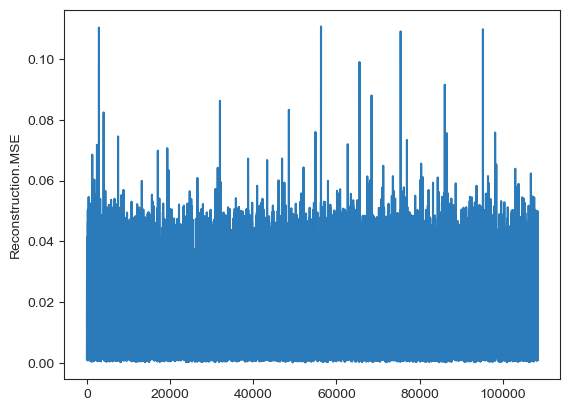

In [153]:
_ = sns.lineplot (x=train_mse.index, y=train_mse['Reconstruction.MSE'],  color="#2b7bba")

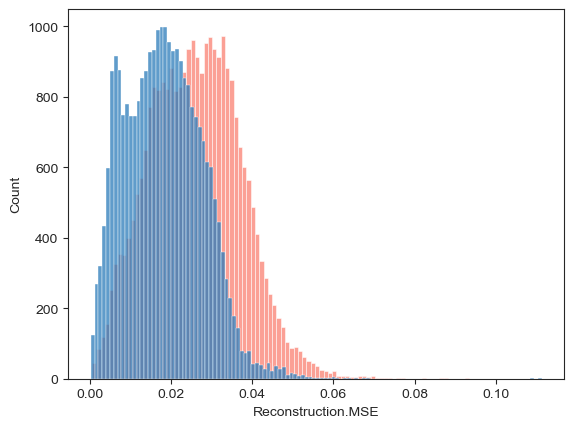

In [154]:
_ = sns.histplot (positive_mse['Reconstruction.MSE'], color="Salmon")
_ = sns.histplot (negative_mse['Reconstruction.MSE'], color="#2b7bba")

In [155]:
def confusion_matrix (negative_mse, positive_mse, neg_round, pos_round):
    
    neg = negative_mse['Reconstruction.MSE'].values
    pos = positive_mse['Reconstruction.MSE'].values
    
    errors_neg = np.around (neg,neg_round) 
    errors_pos = np.around (pos,pos_round)
    
    errors = np.concatenate ((errors_neg, errors_pos))
    thresholds = np.unique (errors)
    
    
    TPR = []
    FPR = []
    TNR = []
    FNR = []
    
    for t in thresholds:
        tpr = np.count_nonzero(pos > t)/len(pos)
        fpr = np.count_nonzero(neg > t)/len(neg)
        
        fnr = np.count_nonzero(pos <= t)/len(pos)
        tnr = np.count_nonzero(neg <= t)/len(neg)
        
        TPR.append (np.around(tpr,2))
        FNR.append (np.around(fnr,2))
        
        
        TNR.append (np.around(tnr,2))
        FPR.append (np.around(fpr,2))
       
        
    pos_rates = pd.DataFrame (TPR, FPR)
    pos_rates.reset_index(inplace=True)
    pos_rates.rename(columns={'index': "TPR", 0:"FPR"}, inplace=True)
    neg_rates = pd.DataFrame (TNR, FNR)
    neg_rates.reset_index(inplace=True)
    neg_rates.rename(columns={'index': "TNR", 0:"FNR"}, inplace=True)
        
    return TPR, FPR, TNR, FNR

In [156]:
def plot_roc_curve(fpr, tpr):

    fig, ax = plt.subplots(ncols=1, nrows=1) 
                                         
    ax.set_ylabel("True Positive Rate")
    ax.set_xlabel("False Positive Rate")

    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend()
    plt.show()

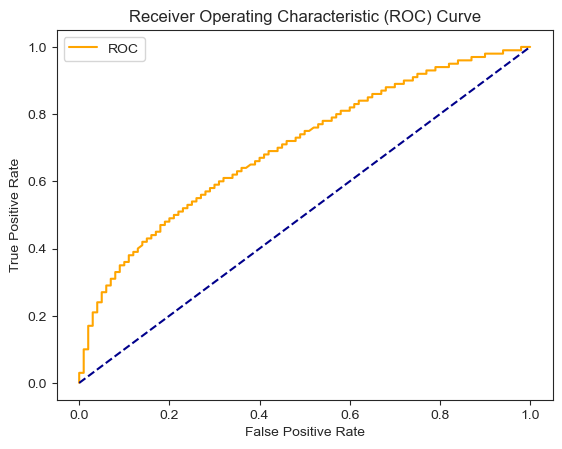

In [157]:
TPR, FPR, TNR, FNR = confusion_matrix (negative_mse, positive_mse, 5, 4)
_ = plot_roc_curve (FPR, TPR)

In [158]:
demand_train.head()

,Hour,Minute,Temperature,DewPoint,Humidity,WindSpeed,WindGust,Pressure,Precipitation,Month,Weekday,Demand_0,Demand_15,Demand_30,Demand_45,Demand_60,Demand_mean,Demand_sd
22837,21,15,17.0,11.0,67.0,9.0,0.0,980.42,0.0,8,0,237.9,235.0,219.1,226.3,229.7,229.60,7.402702
1197,11,15,-7.0,-14.0,57.0,0.0,0.0,989.53,0.0,1,6,224.9,223.3,212.0,216.4,218.7,219.06,5.223313
19113,2,15,22.0,22.0,100.0,9.0,0.0,973.26,0.0,7,4,238.6,236.0,236.7,239.5,239.9,238.14,1.718430
11393,16,15,11.0,-2.0,40.0,11.0,0.0,976.19,0.0,4,3,263.0,264.8,263.0,263.1,268.1,264.40,2.205675
6076,7,0,-4.0,-8.0,77.0,15.0,0.0,982.05,0.0,3,0,228.6,231.2,228.1,228.3,226.9,228.62,1.580190


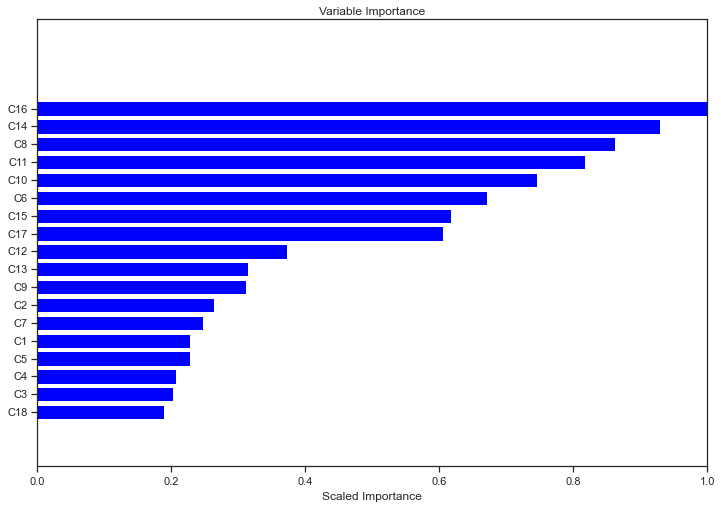

In [632]:
anomaly_model._model_json['output']['variable_importances'].as_data_frame()
# plotting the variable importance

fig, ax = plt.subplots(figsize = (12, 8))

variables = anomaly_model._model_json['output']['variable_importances']['variable']
var = variables[0:22]
y_pos = np.arange(len(var))

scaled_importance = anomaly_model._model_json['output']['variable_importances']['scaled_importance']
sc = scaled_importance[0:22]

ax.barh(y_pos, sc, align='center', color='blue', ecolor='black')
ax.set_yticks(y_pos)
ax.set_yticklabels(variables)
ax.invert_yaxis()
ax.set_xlabel('Scaled Importance')
ax.set_title('Variable Importance')
plt.show()

## Fitting data to a distribution ##

In [ ]:
%matplotlib inline

import warnings
import numpy as np
import pandas as pd
import scipy.stats as st
import statsmodels as sm
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.figsize'] = (16.0, 12.0)
matplotlib.style.use('ggplot')

# Create models from data
def best_fit_distribution(data, bins=200, ax=None):
    """Model data by finding best fit distribution to data"""
    # Get histogram of original data
    y, x = np.histogram(data, bins=bins, density=True)
    x = (x + np.roll(x, -1))[:-1] / 2.0

    # Distributions to check
    
    DISTRIBUTIONS = [        
        st.alpha,st.anglit,st.arcsine,st.beta,st.betaprime,st.bradford,st.burr,st.cauchy,st.chi,st.chi2,st.cosine,
        st.dgamma,st.dweibull,st.erlang,st.expon,st.exponnorm,st.exponweib,st.exponpow,st.f,st.fatiguelife,st.fisk,
        st.foldcauchy,st.foldnorm, st.genlogistic,st.genpareto,st.gennorm,st.genexpon,
        st.genextreme,st.gausshyper,st.gamma,st.gengamma,st.genhalflogistic,st.gilbrat,st.gompertz,st.gumbel_r,
        st.gumbel_l,st.halfcauchy,st.halflogistic,st.halfnorm,st.halfgennorm,st.hypsecant,st.invgamma,st.invgauss,
        st.pareto,st.pearson3,st.powerlaw,st.powerlognorm,st.weibull_max,st.wrapcauchy
    ]

    # Best holders
    best_distribution = st.norm
    best_params = (0.0, 1.0)
    best_sse = np.inf

    # Estimate distribution parameters from data
    for distribution in DISTRIBUTIONS:

        # Try to fit the distribution
        try:
            # Ignore warnings from data that can't be fit
            with warnings.catch_warnings():
                warnings.filterwarnings('ignore')

                # fit dist to data
                params = distribution.fit(data)

                # Separate parts of parameters
                arg = params[:-2]
                loc = params[-2]
                scale = params[-1]

                # Calculate fitted PDF and error with fit in distribution
                pdf = distribution.pdf(x, loc=loc, scale=scale, *arg)
                sse = np.sum(np.power(y - pdf, 2.0))

                # if axis pass in add to plot
                try:
                    if ax:
                        pd.Series(pdf, x).plot(ax=ax)
                    end
                except Exception:
                    pass

                # identify if this distribution is better
                if best_sse > sse > 0:
                    best_distribution = distribution
                    best_params = params
                    best_sse = sse

        except Exception:
            pass

    return (best_distribution.name, best_params)

def make_pdf(dist, params, size=10000):
    """Generate distributions's Probability Distribution Function """

    # Separate parts of parameters
    arg = params[:-2]
    loc = params[-2]
    scale = params[-1]

    # Get sane start and end points of distribution
    start = dist.ppf(0.01, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.01, loc=loc, scale=scale)
    end = dist.ppf(0.99, *arg, loc=loc, scale=scale) if arg else dist.ppf(0.99, loc=loc, scale=scale)

    # Build PDF and turn into pandas Series
    x = np.linspace(start, end, size)
    y = dist.pdf(x, loc=loc, scale=scale, *arg)
    pdf = pd.Series(y, x)

    return pdf

# Load data from statsmodels datasets

data = peak_demand_hours ['Demand_mean']
# data = low_demand_hours ['Demand_mean']
# data = demand_weekend['Demand_mean']

# Plot for comparison
plt.figure(figsize=(12,8))
ax = data.plot(kind='hist', bins=50, alpha=0.5)
# Save plot limits
dataYLim = ax.get_ylim()

# Find best fit distribution
best_fit_name, best_fit_params = best_fit_distribution(data, 200, ax)
best_dist = getattr(st, best_fit_name)

# Update plots
ax.set_ylim(dataYLim)
ax.set_title(u'El Niño sea temp.\n All Fitted Distributions')
ax.set_xlabel(u'Temp (°C)')
ax.set_ylabel('Frequency')

# Make PDF with best params 
pdf = make_pdf(best_dist, best_fit_params)

# Display
plt.figure(figsize=(12,8))
ax = pdf.plot(lw=2, label='PDF', legend=True)
data.plot(kind='hist', bins=50, alpha=0.5, label='Data', legend=True, ax=ax)

param_names = (best_dist.shapes + ', loc, scale').split(', ') if best_dist.shapes else ['loc', 'scale']
param_str = ', '.join(['{}={:0.2f}'.format(k,v) for k,v in zip(param_names, best_fit_params)])
dist_str = '{}({})'.format(best_fit_name, param_str)

ax.set_title(u'El Niño sea temp. with best fit distribution \n' + dist_str)
ax.set_xlabel(u'Temp. (°C)')
ax.set_ylabel('Frequency')